# Integrantes:

---

1. Luisa Fernanda Guerrero Ordoñez - 20212020099
2. Oscar Santiago Duran Benitez - 20212020080
3. Jefferson David Ortiz Buitrago - 20221020110
4. Miguel Angel Torres Ramirez - 20222020130

# Análisis Exploratorio: Depresión en Estudiantes Universitarios

**Dataset:** `Student_Depression_Dataset.csv`  
**Registros:** 27,901 estudiantes | **Variables:** 18

## Comprensión del Problema

---

La depresión en estudiantes universitarios es una problemática de salud mental con impacto directo en el rendimiento académico, la calidad de vida y el riesgo de abandono estudiantil. Este análisis busca identificar los factores que influyen en la presencia de depresión en estudiantes, utilizando variables relacionadas con presión académica, hábitos de vida, situación financiera y antecedentes personales.

Desde el enfoque de minería de datos, este problema es principalmente de tipo explicativo, ya que se busca entender qué variables están asociadas con la depresión, y potencialmente predictivo, dado que los hallazgos podrían utilizarse en el futuro para construir modelos que identifiquen estudiantes en riesgo.

Los resultados de este análisis podrían ser utilizados por instituciones educativas, psicólogos y entidades de salud para diseñar estrategias de intervención temprana, prevención y acompañamiento a estudiantes.

La variable más importante a analizar es "Depression", ya que representa el fenómeno de interés y permite evaluar cómo se relaciona con el resto de variables.

Un riesgo importante en este análisis es confundir correlación con causalidad. Por ejemplo, una alta presión académica puede estar asociada con la depresión, pero no necesariamente ser la causa directa. Interpretar incorrectamente estas relaciones podría llevar a decisiones erróneas en contextos reales.

## Incógnitas que nos gustaría resolver

---

¿Los estudiantes con mayor presión académica y estrés financiero tienen mayor probabilidad de presentar depresión?

¿Existen diferencias en los niveles de depresión según el género, los hábitos de sueño y los hábitos alimenticios del estudiante?

## Enfoque del análisis

Las incógnitas planteadas permiten abordar el problema buscando identificar relaciones entre variables como la presión académica, el estrés financiero y los hábitos de vida con la depresión.

A partir de estas preguntas esperamos identificar qué variables tienen mayor influencia y cómo podrían utilizarse para la toma de decisiones en contextos educativos.

## PARTE 1 — Análisis en Bruto

## 1.1 Cargar el Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

df = pd.read_csv("/content/drive/MyDrive/Bases/Student Depression Dataset.csv")

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.head(10)

Mounted at /content/drive
Filas: 27,901  |  Columnas: 18


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1


## 1.2 Tipos de datos

In [ ]:
print(df.dtypes)

print("\nPROBLEMAS IDENTIFICADOS")
problemas = {
    'id'                                   : 'Identificador — no aporta información al análisis',
    'Sleep Duration'                       : 'Ordinal (Less than 5h < 5-6h < 7-8h < More than 8h) tratada como texto sin orden',
    'Dietary Habits'                       : 'Ordinal (Unhealthy < Moderate < Healthy) tratada como texto sin orden',
    'Have you ever had suicidal thoughts ?' : 'Binaria Sí/No almacenada como texto, debe ser 0/1',
    'Family History of Mental Illness'     : 'Binaria Sí/No almacenada como texto, debe ser 0/1',
    'Gender'                               : 'Nominal',
    'City'                                 : 'Tiene valores corruptos mezclados (nombres de personas, títulos de programas)',
    'Profession'                           : '99.9% son estudiantes (no aporta variabilidad al análisis)',
    'Financial Stress'                     : 'Tiene 3 valores nulos',
}
for col, prob in problemas.items():
    print(f" {col}: {prob}")

id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

PROBLEMAS IDENTIFICADOS
 id: Identificador — no aporta información al análisis
 Sleep Duration: Ordinal

## Análisis

---
Lo primero que notamos es que hay una mezcla de variables numéricas y categóricas donde varias de las categóricas tienen un orden lógico implícito que pandas no reconoce automáticamente, como Sleep Duration que va de menos de 5 horas hasta más de 8 horas, o Dietary Habits que va de hábitos poco saludables a saludables.

También identificamos variables binarias almacenadas como texto como "Have you ever had suicidal thoughts?" y "Family History of Mental Illness" que solo pueden valer Sí o No pero están guardadas como palabras, lo que impide usarlas en cálculos directamente.

La variable id es solo un identificador y no aporta ninguna información útil sobre el comportamiento de los estudiantes. Y la columna Profession tiene el 99.9% de sus registros como "Student", por lo que tampoco aporta variabilidad y puede descartarse.

Por último encontramos que la columna City tiene valores corruptos donde aparecen nombres de personas, títulos de programas académicos y textos sin sentido mezclados con nombres de ciudades reales, lo que indica problemas en la captura original de los datos, sin embargo en lugar de eliminar la variable eliminaremos los resgistros con el dato corrupto.

## 1.3 Identificar valores nulos y duplicados

In [ ]:
print("Valores nulos")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos")

print(f"\nDuplicados")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"IDs únicos: {df['id'].nunique()} / {len(df)}")

print("\nEstadísticas descriptivas")
df.describe().round(2)

Valores nulos
Financial Stress    3
dtype: int64

Duplicados
Filas duplicadas: 0
IDs únicos: 27901 / 27901

Estadísticas descriptivas


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27898.00,27901.00
mean,70442.15,25.82,3.14,0.00,7.66,2.94,0.00,7.16,3.14,0.59
std,40641.18,4.91,1.38,0.04,1.47,1.36,0.04,3.71,1.44,0.49
min,2.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,35039.00,21.00,2.00,0.00,6.29,2.00,0.00,4.00,2.00,0.00
50%,70684.00,25.00,3.00,0.00,7.77,3.00,0.00,8.00,3.00,1.00
75%,105818.00,30.00,4.00,0.00,8.92,4.00,0.00,10.00,4.00,1.00
max,140699.00,59.00,5.00,5.00,10.00,5.00,4.00,12.00,5.00,1.00


## Análisis

---

La variable Financial Stress tiene 3 registros sin dato. Aunque son apenas 3 casos sobre 27,901 esto es el tipo de situación que debemos manejar en la Parte 2 al limpiar los datos para no generar errores en los modelos.

No hay filas duplicadas y cada id es único, lo que confirma que cada fila representa a un estudiante diferente.

En las estadísticas descriptivas llama la atención que Work Pressure y Job Satisfaction tienen media casi cero, lo que tiene sentido porque prácticamente todos los registros corresponden a estudiantes que no trabajan.

## 1.4 Gráficas antes de transformar los datos

##Histogramas


---



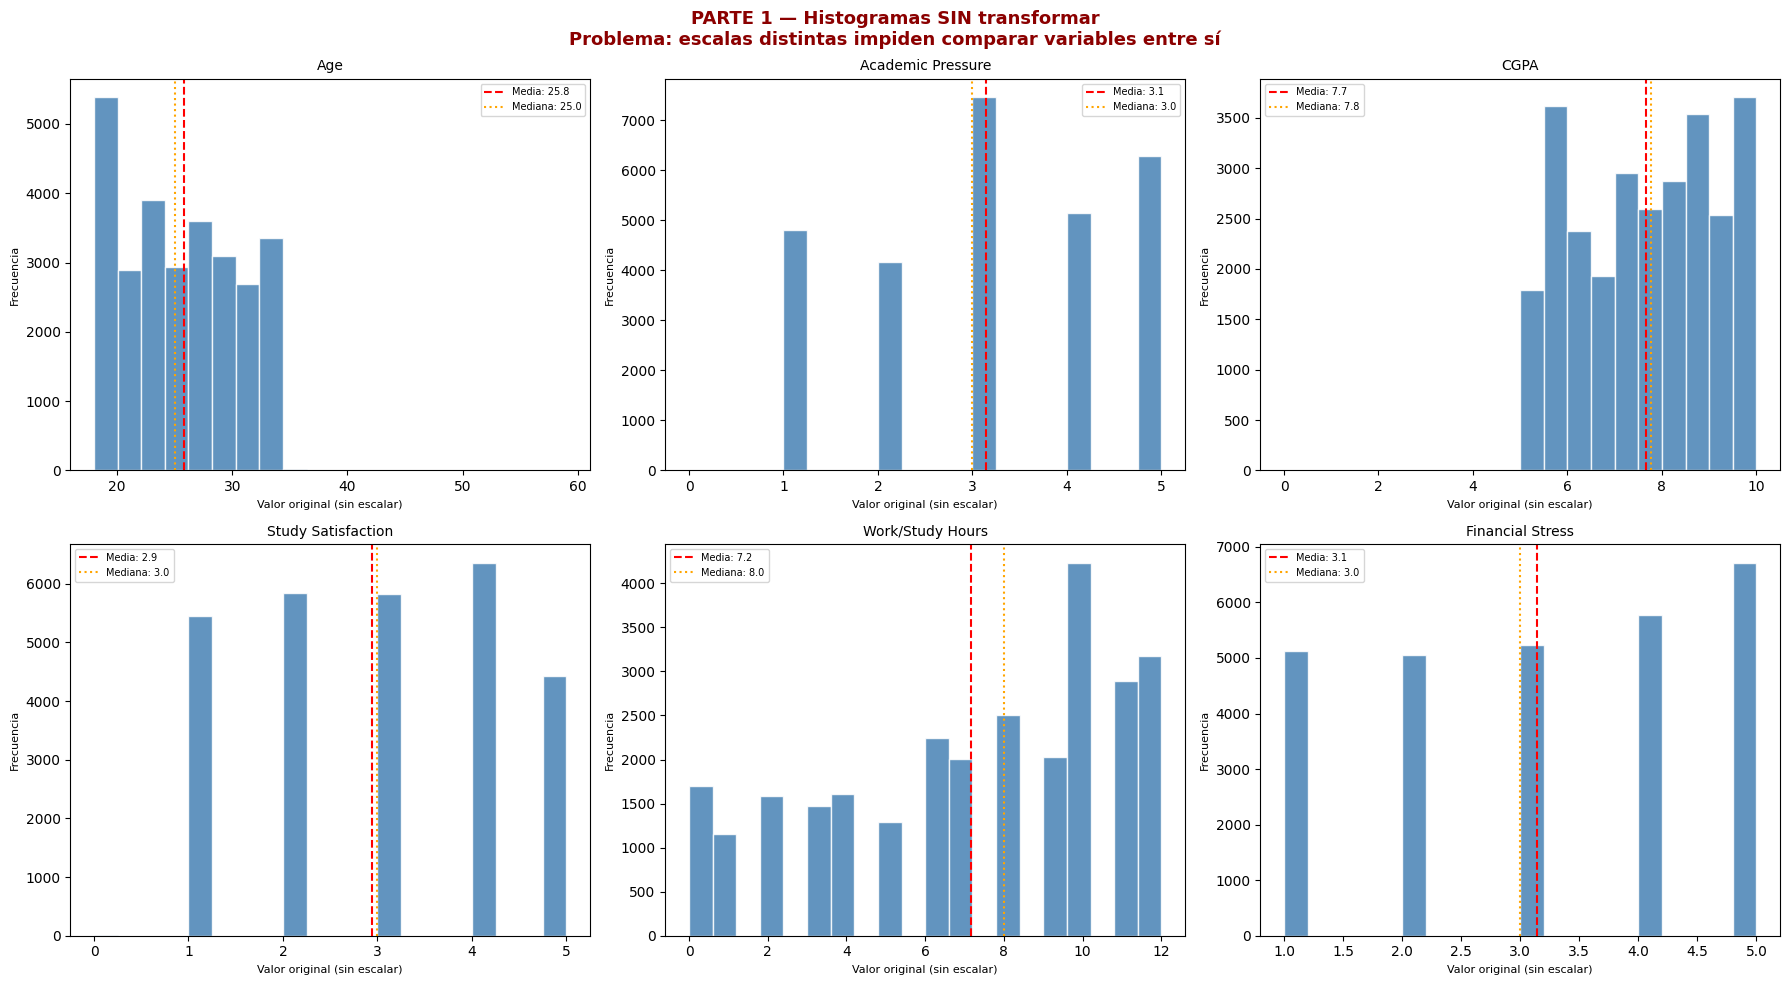

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

num_cols = [
    'Age', 'Academic Pressure', 'CGPA',
    'Study Satisfaction', 'Work/Study Hours', 'Financial Stress'
]

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':', linewidth=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Valor original (sin escalar)', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('PARTE 1 — Histogramas SIN transformar\n'
             'Problema: escalas distintas impiden comparar variables entre sí',
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

## Interpretación

---
Age muestra una distribución con sesgo hacia la derecha, la mayoría de estudiantes están entre 18 y 30 años pero hay casos que llegan hasta los 59 lo que indica la presencia de estudiantes adultos o de posgrado.

Academic Pressure se concentra en valores medios entre 2 y 4 sobre 5. CGPA muestra una distribución con un pico alrededor de 8, indicando que la mayoría de estudiantes tiene buen rendimiento académico. Work/Study Hours tiene una distribución más dispersa con estudiantes que van desde 0 hasta 12 horas diarias

El problema es que las escalas son completamente distintas entre variables (Age va de 18 a 59, CGPA de 0 a 10, Financial Stress de 1 a 5) lo que hace muy dificil compararlas visualmente.

##Boxplot


---


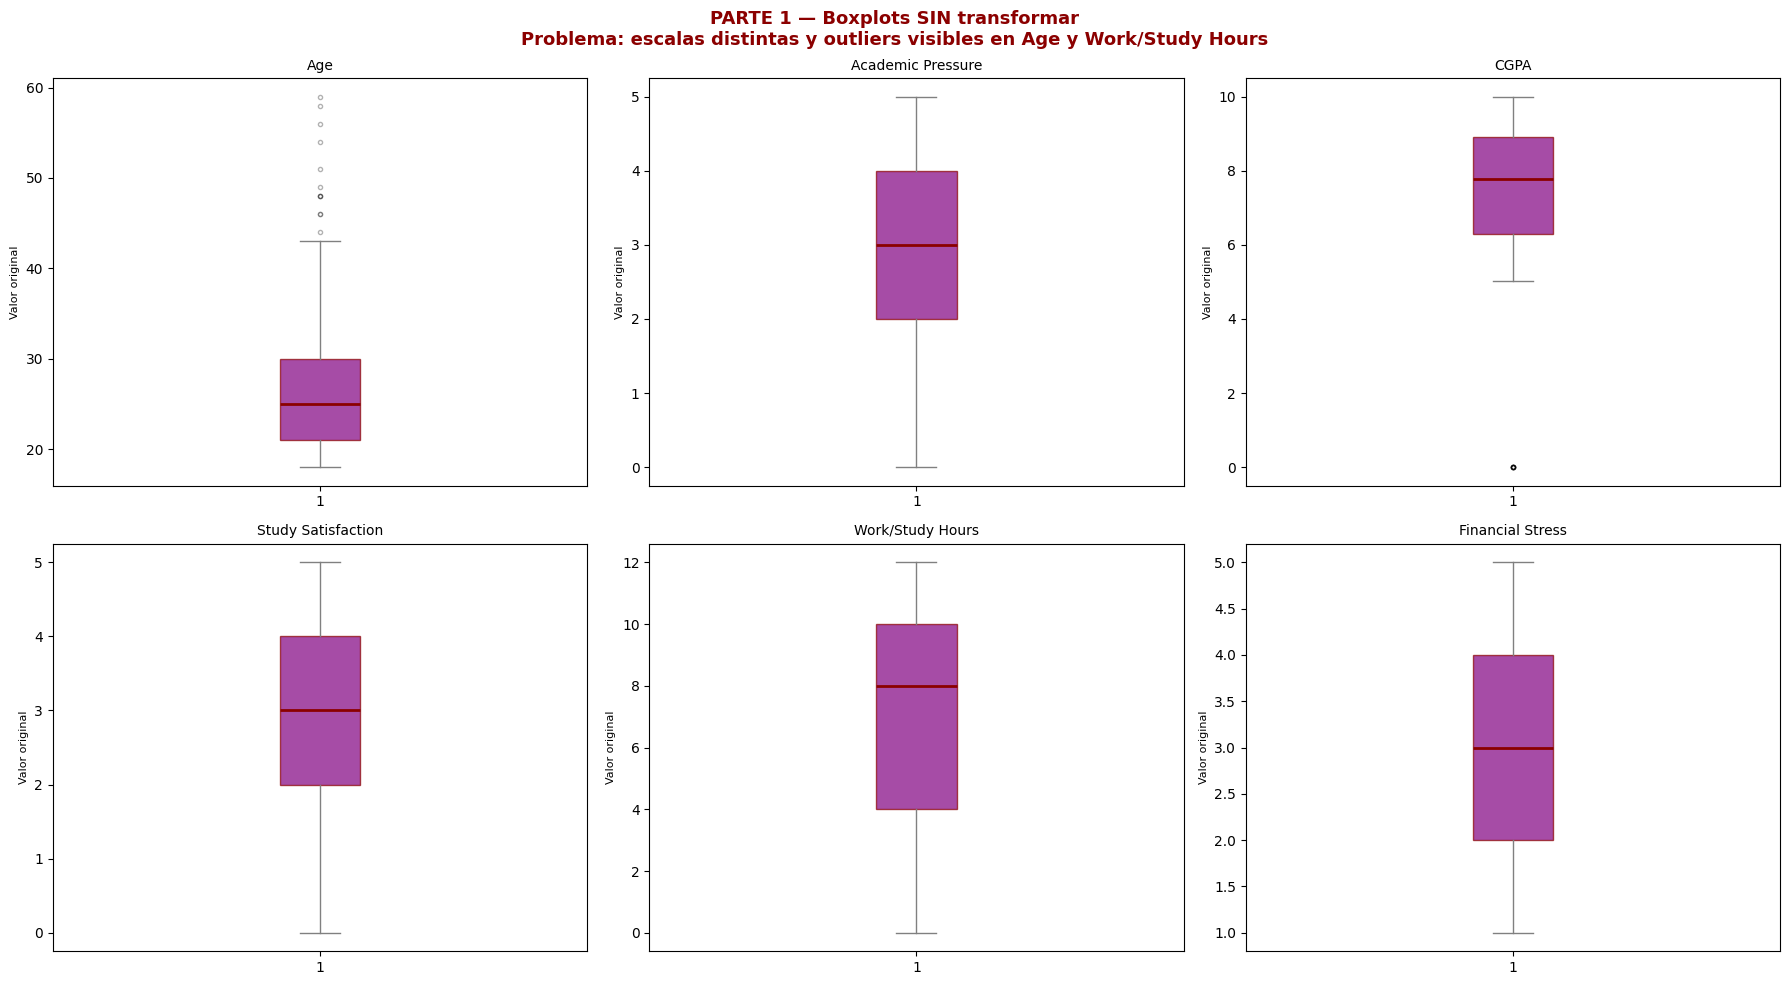

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='purple', color='darkred', alpha=0.7),
               medianprops=dict(color='darkred', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Valor original', fontsize=8)

plt.suptitle('PARTE 1 — Boxplots SIN transformar\n'
             'Problema: escalas distintas y outliers visibles en Age y Work/Study Hours',
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

## Interpretación

---
En Age se observan puntos por encima de los 40 años que están separados de la distribución principal de estudiantes jóvenes. En Work/Study Hours también aparecen valores extremos hacia las 12 horas diarias que se alejan del comportamiento típico.

Al igual que antes la comparación entre variables en este punto sigue siendo problemática por las escalas distintas. Age con valores hasta 59 no es comparable visualmente con Financial Stress que solo llega hasta 5.

##Categorías


---



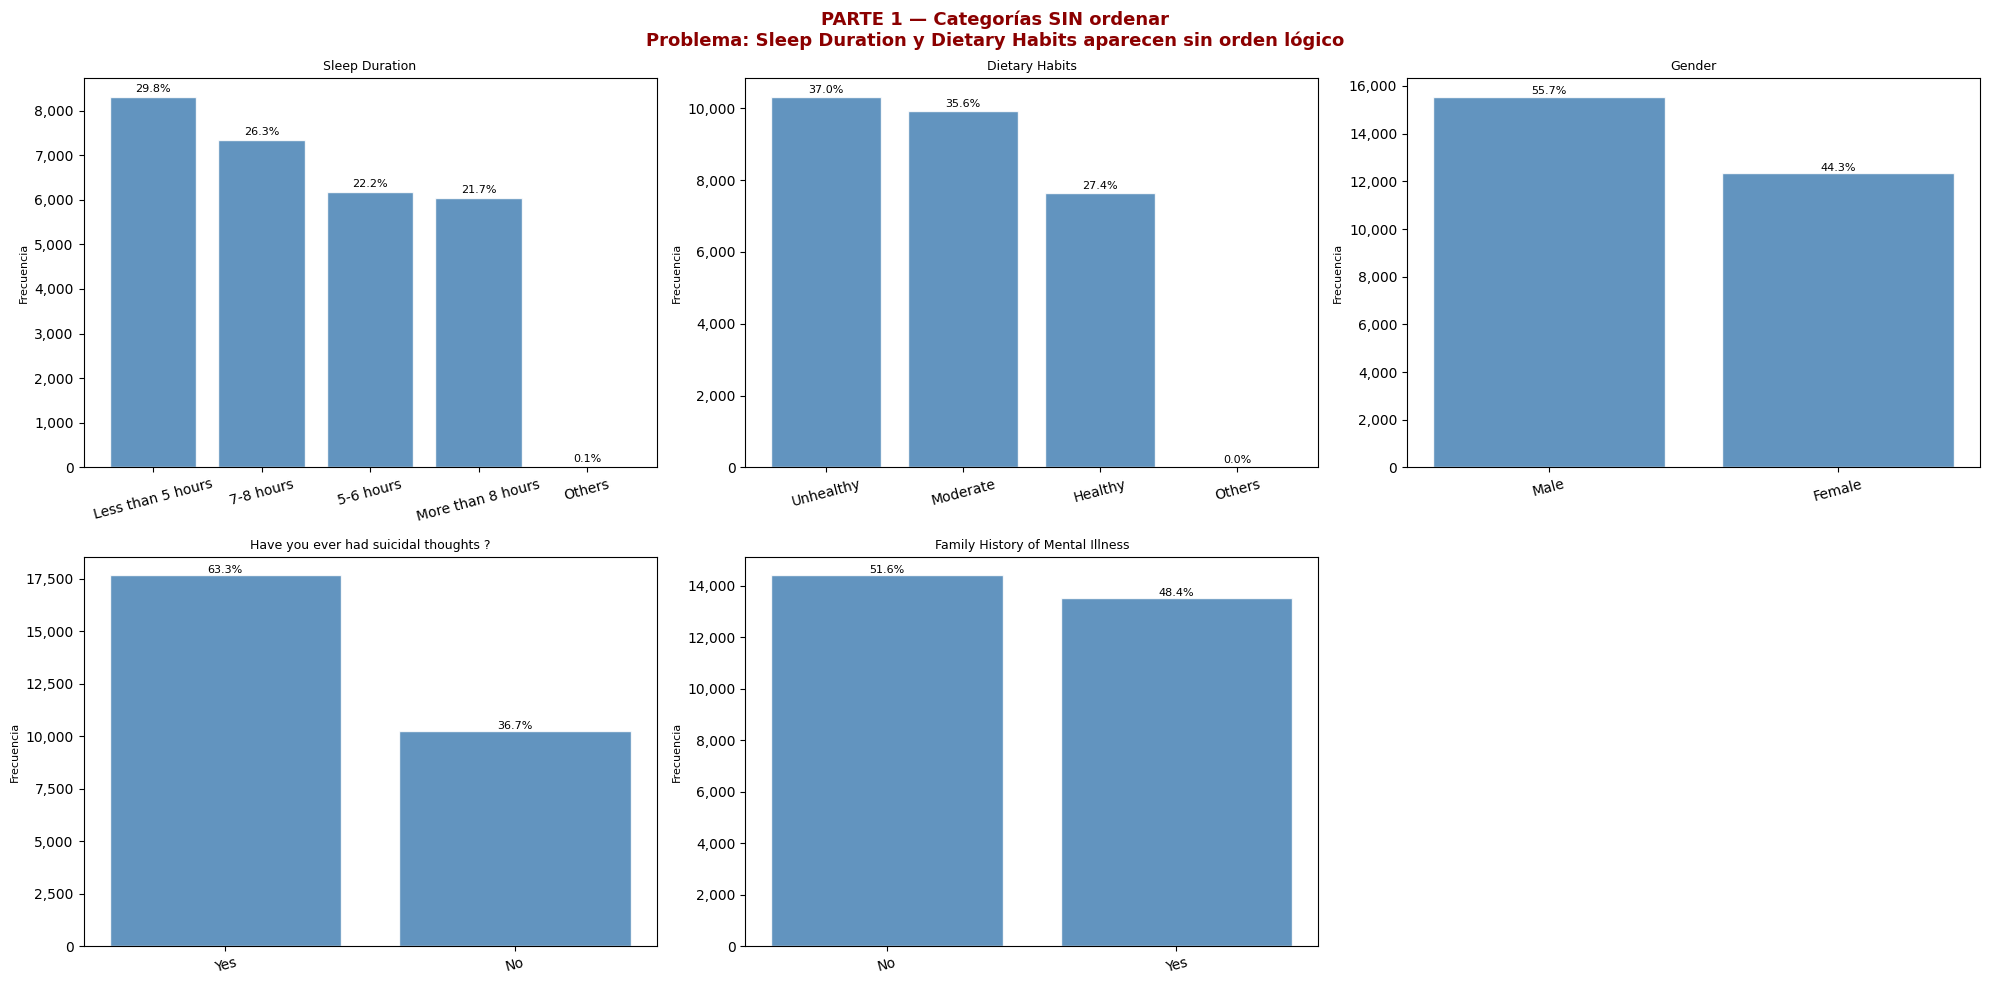

In [ ]:
cat_cols = ['Sleep Duration', 'Dietary Habits', 'Gender',
            'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=8)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 100, f'{v/len(df)*100:.1f}%', ha='center', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=15)

axes[-1].axis('off')

plt.suptitle('PARTE 1 — Categorías SIN ordenar\n'
             'Problema: Sleep Duration y Dietary Habits aparecen sin orden lógico',
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

## Interpretación

---

Aquí se observa uno de los problemas más importantes de trabajar sin antes preparar nuestros datos. Sleep Duration aparece en el gráfico sin ningún orden lógico, se observa que las barras no siguen la secuencia natural de menos horas a más horas sino el orden en que pandas las encontró, lo que impide ver cualquier tendencia entre dormir poco y dormir mucho.

Lo mismo ocurre con Dietary Habits donde los hábitos no están ordenados de menos saludable a más saludable.

También notamos que el 63.3% de los estudiantes reporta haber tenido pensamientos suicidas, lo que es una cifra alta y que en esta etapa no podemos cruzar con otras variables porque está almacenada como texto Yes/No y no como número.

Por último, los hábitos alimenticios muestran que la mayoría de estudiantes tiene hábitos poco saludables o moderados, y apenas el 27.4% tiene una dieta saludable, lo cual es un factor de riesgo para la salud mental que analizaremos mejor en la Parte 2.

##Cruce de variables


---



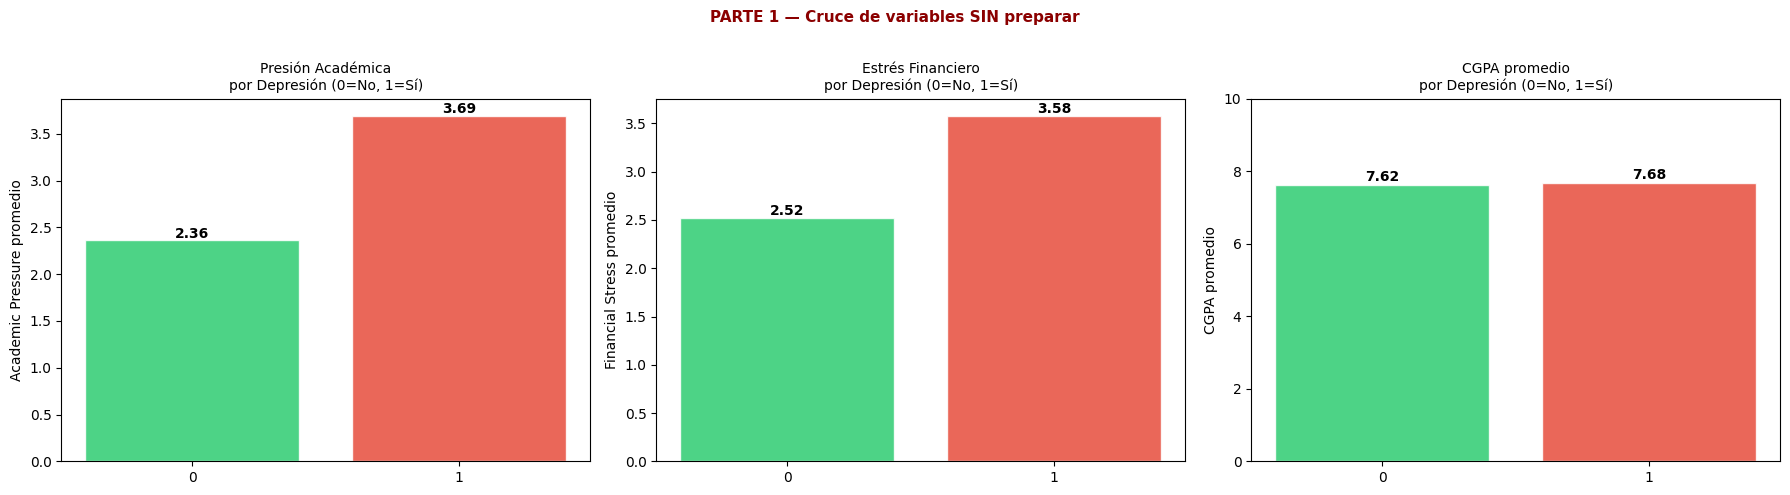

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Presión académica por depresión
medias_ap = df.groupby('Depression')['Academic Pressure'].mean()
axes[0].bar(medias_ap.index.astype(str), medias_ap.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white', alpha=0.85)
axes[0].set_title('Presión Académica\npor Depresión (0=No, 1=Sí)', fontsize=10)
axes[0].set_ylabel('Academic Pressure promedio')
for i, v in enumerate(medias_ap.values):
    axes[0].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Estrés financiero por depresión
medias_fs = df.groupby('Depression')['Financial Stress'].mean()
axes[1].bar(medias_fs.index.astype(str), medias_fs.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white', alpha=0.85)
axes[1].set_title('Estrés Financiero\npor Depresión (0=No, 1=Sí)', fontsize=10)
axes[1].set_ylabel('Financial Stress promedio')
for i, v in enumerate(medias_fs.values):
    axes[1].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# CGPA por depresión
medias_cgpa = df.groupby('Depression')['CGPA'].mean()
axes[2].bar(medias_cgpa.index.astype(str), medias_cgpa.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white', alpha=0.85)
axes[2].set_title('CGPA promedio\npor Depresión (0=No, 1=Sí)', fontsize=10)
axes[2].set_ylabel('CGPA promedio')
axes[2].set_ylim(0, 10)
for i, v in enumerate(medias_cgpa.values):
    axes[2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('PARTE 1 — Cruce de variables SIN preparar\n',
             fontsize=11, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

## Interpretación

---

Los estudiantes con depresión tienen en promedio una presión académica de 3.69 sobre 5, mientras que los que no tienen depresión promedian 2.36. Esa diferencia de más de un punto completo en una escala de 5 es significativa y sugiere que la presión académica sí está relacionada con la depresión.

Lo mismo ocurre con el estrés financiero ya que el grupo con depresión promedia 3.58 frente a 2.52 del grupo sin depresión. El CGPA en cambio es prácticamente igual entre ambos grupos (7.68 vs 7.62), lo que indica que el rendimiento académico por sí solo no distingue a quienes tienen depresión de quienes no.

Sin embargo variables como Sleep Duration y Dietary Habits que podrían ser muy informativas todavía no se pueden cruzar con depresión porque están almacenadas como texto.


##Matriz de correlación


---



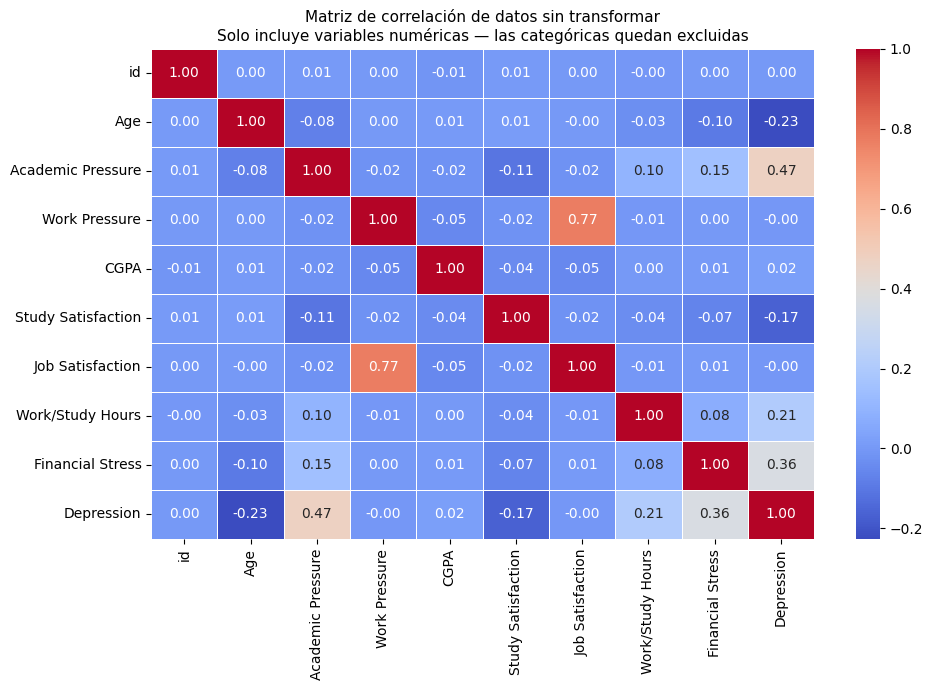


Correlaciones con Depression (sin transformar):
Age                  -0.226
Study Satisfaction   -0.168
Job Satisfaction     -0.003
Work Pressure        -0.003
id                    0.001
CGPA                  0.022
Work/Study Hours      0.209
Financial Stress      0.364
Academic Pressure     0.475
Depression            1.000
Name: Depression, dtype: float64


In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de correlación de datos sin transformar\n"
          "Solo incluye variables numéricas — las categóricas quedan excluidas",
          fontsize=11)
plt.tight_layout()
plt.show()

print("\nCorrelaciones con Depression (sin transformar):")
print(df.corr(numeric_only=True)['Depression'].sort_values().round(3))

## Interpretación

---

Academic Pressure tiene una correlación de 0.47 con Depression y Financial Stress de 0.36, valores que se consideran correlaciones moderadas-altas y estadísticamente relevantes.

Sin embargo, el mapa está incompleto. Variables que intuitivamente deberían ser importantes como Sleep Duration, Dietary Habits, pensamientos suicidas y antecedentes familiares no aparecen en la correlación porque están almacenadas como texto.

## Relevancia de variables y calidad de datos

---

A partir del análisis inicial, se identifican como variables más relevantes aquellas relacionadas con presión académica, estrés financiero y salud mental, ya que están directamente vinculadas con la variable objetivo (Depression).

También se detectan problemas de calidad en los datos, como variables categóricas mal estructuradas, valores corruptos y variables sin variabilidad, lo que puede afectar el análisis si no se corrige adecuadamente.

## Analisis de sesgos

---

Antes de iniciar con la limpieza y transformación de los datos identificamos los posibles sesgos y limitaciones que puedan afectar la interpretación de los resultados y el dataset presenta varias limitaciones que deben tenerse en cuenta al interpretar los resultados.

Lo primero es que existe un sesgo geográfico ya que los datos provienen de estudiantes en India. Esto implica que los resultados no necesariamente se pueden generalizar a estudiantes de otros países o contextos culturales.

También se evidencia un posible sesgo de autopercepción ya que muchas variables como presión académica, estrés o depresión provienen de encuestas y cada estudiante puede interpretar estas variables de manera diferente.

Por ultimo, la alta proporción de estudiantes que reportan haber tenido pensamientos suicidas (63.3%) sugiere un posible sesgo en la muestra o en la recolección de datos lo cual puede afectar la representatividad del dataset.

## PARTE 2 — Limpieza y Transformación

## 2.1 Eliminar variables que causan ruido y corregir errores

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

df = pd.read_csv("/content/drive/MyDrive/Bases/Student Depression Dataset.csv")
df2 = df.copy()

# 1. Eliminar id — solo es un identificador
df2.drop(columns=['id'], inplace=True)
print("id eliminado")

# 2. Eliminar Profession — 99.9% son estudiantes, no aporta variabilidad
print(f"   Profession — valores únicos: {df2['Profession'].value_counts().to_dict()}")
df2.drop(columns=['Profession'], inplace=True)
print("Profession eliminado")

# 3. Eliminar registros corruptos de City — nombres de personas y valores sin sentido
#    Se conserva la columna pero se eliminan los 26 registros con datos incorrectos
ciudades_validas = df2['City'].value_counts()
ciudades_validas = ciudades_validas[ciudades_validas >= 3].index.tolist()
registros_antes = len(df2)
df2 = df2[df2['City'].isin(ciudades_validas)].reset_index(drop=True)
print(f"City — registros corruptos eliminados: {registros_antes - len(df2)}")
print(f"   Ciudades conservadas: {df2['City'].nunique()}")

# 4. Eliminar Work Pressure y Job Satisfaction — media ~0, sin variabilidad útil
df2.drop(columns=['Work Pressure', 'Job Satisfaction'], inplace=True)
print("'Work Pressure' y 'Job Satisfaction' eliminados")

print(f"\nDimensiones: {df2.shape[0]:,} filas × {df2.shape[1]} columnas")
print("Variables restantes:", df2.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
id eliminado
   Profession — valores únicos: {'Student': 27870, 'Architect': 8, 'Teacher': 6, 'Digital Marketer': 3, 'Chef': 2, 'Content Writer': 2, 'Pharmacist': 2, 'Doctor': 2, 'UX/UI Designer': 1, 'Civil Engineer': 1, 'Manager': 1, 'Educational Consultant': 1, 'Lawyer': 1, 'Entrepreneur': 1}
Profession eliminado
City — registros corruptos eliminados: 26
   Ciudades conservadas: 30
'Work Pressure' y 'Job Satisfaction' eliminados

Dimensiones: 27,875 filas × 14 columnas
Variables restantes: ['Gender', 'Age', 'City', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


## ¿Por qué eliminamos estas variables?

---

Eliminamos cinco variables en total por razones distintas.

id es un identificador sin información.

Profession se eliminó porque el 99.8% de los registros tiene el valor "Student". Una variable que casi no varía no le aporta nada al análisis y solo genera ruido.

En City encontramos 26 registros con valores corruptos ya que aparecen nombres de personas como "Saanvi", "Bhavna" y "Harsha", títulos académicos como "M.Tech" y textos sin sentido como "Less than 5 Kalyan". En lugar de eliminar toda la columna, eliminamos únicamente esos 26 registros problemáticos conservando la información geográfica del resto. Esto nos permite mantener City en el dataset por si fuera útil en análisis posteriores por región.

Work Pressure y Job Satisfaction se eliminaron porque tienen de media prácticamente cero, lo que indica que casi ningún estudiante trabaja.

## Impacto de la limpieza

---

Si no realizaramos la limpieza el análisis podría verse afectado por ruido, variables irrelevantes y datos inconsistentes lo que nos dificultaría la identificación de patrones reales. Las decisiones que tomamos como eliminar variables o imputar valores pueden influir en los resultados. Por ejemplo, imputar valores reduce la variabilidad mientras que eliminar datos puede implicar pérdida de información.

## 2.2 Tratar valores nulos

In [ ]:
print("Nulos antes del tratamiento:")
print(df2.isnull().sum()[df2.isnull().sum() > 0])

# Sustituir los 3 nulos de Financial Stress con la mediana
mediana_fs = df2['Financial Stress'].median()
df2['Financial Stress'].fillna(mediana_fs, inplace=True)

print(f"\nFinancial Stress: 3 nulos imputados con mediana ({mediana_fs})")
print(f"\nNulos después del tratamiento:")
print(df2.isnull().sum()[df2.isnull().sum() > 0] if df2.isnull().sum().sum() > 0
      else "Sin valores nulos")

Nulos antes del tratamiento:
Financial Stress    3
dtype: int64

Financial Stress: 3 nulos imputados con mediana (3.0)

Nulos después del tratamiento:
Sin valores nulos


## ¿Por qué usamos la mediana y no la media?

---

Cuando hay valores nulos en una variable numérica tenemos dos opciones principales que es utilizar la media o la mediana. En este caso elegimos la mediana porque es más robusta (o menos sensible) frente a valores extremos

## 2.3 Codificar variables categóricas

In [ ]:
# Variables ordinales — tienen orden lógico
df2['Sleep_enc'] = df2['Sleep Duration'].map({
    'Less than 5 hours': 0,
    '5-6 hours'        : 1,
    '7-8 hours'        : 2,
    'More than 8 hours': 3,
    'Others'           : np.nan
})

df2['Dietary_enc'] = df2['Dietary Habits'].map({
    'Unhealthy': 0,
    'Moderate' : 1,
    'Healthy'  : 2,
    'Others'   : np.nan
})

# Variables binarias pasarlas de Yes/No → 1/0
df2['Suicidal_enc']       = df2['Have you ever had suicidal thoughts ?'].map({'No': 0, 'Yes': 1})
df2['Family_History_enc'] = df2['Family History of Mental Illness'].map({'No': 0, 'Yes': 1})
df2['Gender_enc']         = df2['Gender'].map({'Male': 0, 'Female': 1})

print("Variables codificadas:")
for col in ['Sleep_enc','Dietary_enc','Suicidal_enc','Family_History_enc','Gender_enc']:
    nulos = df2[col].isna().sum()
    print(f"  {col:25} | nulos: {nulos}")

print(f"\nDimensiones: {df2.shape[0]:,} filas × {df2.shape[1]} columnas")
df2[['Sleep Duration','Sleep_enc','Dietary Habits','Dietary_enc',
     'Have you ever had suicidal thoughts ?','Suicidal_enc']].head()

Variables codificadas:
  Sleep_enc                 | nulos: 18
  Dietary_enc               | nulos: 12
  Suicidal_enc              | nulos: 0
  Family_History_enc        | nulos: 0
  Gender_enc                | nulos: 0

Dimensiones: 27,875 filas × 19 columnas


,Sleep Duration,Sleep_enc,Dietary Habits,Dietary_enc,Have you ever had suicidal thoughts ?,Suicidal_enc
0,5-6 hours,1.0,Healthy,2.0,Yes,1
1,5-6 hours,1.0,Moderate,1.0,No,0
2,Less than 5 hours,0.0,Healthy,2.0,No,0
3,7-8 hours,2.0,Moderate,1.0,Yes,1
4,5-6 hours,1.0,Moderate,1.0,Yes,1


## ¿Por qué codificamos de esta manera?

---
Para Sleep Duration y Dietary Habits aplicamos codificación ordinal porque tienen un orden lógico claro. Asignar 0, 1, 2, 3 respeta esa jerarquía.

Para las variables binarias como pensamientos suicidas, antecedentes familiares y género simplemente convertimos Yes/No y Male/Female a 0 y 1. Esto nos permite incluirlas en la matriz de correlación.

Sleep Duration y Dietary Habits tienen una categoría "Others" que mapeamos como NaN porque no sabemos en qué posición de la escala ubicarla. Son apenas 18 y 12 casos sobre 27,901, por lo que su impacto es mínimo.

## 2.4 Crear variables derivadas

In [ ]:
# Índice de presión total: presión académica y estrés financiero
df2['pressure_index'] = df2['Academic Pressure'] + df2['Financial Stress']

# Índice de hábitos saludables: sueño y alimentación
df2['healthy_habits'] = (
    df2['Sleep_enc'].fillna(0) * 2    # doble peso al sueño
    + df2['Dietary_enc'].fillna(0)
)

# Eficiencia académica: rendimiento relativo a las horas invertidas
df2['academic_efficiency'] = (
    df2['CGPA'] / (df2['Work/Study Hours'] + 0.1)
).round(3)

# Perfil de riesgo: presión + antecedentes + pensamientos suicidas
df2['risk_profile'] = (
    df2['Academic Pressure']
    + df2['Financial Stress']
    + df2['Suicidal_enc'] * 3         # peso mayor por severidad clínica
    + df2['Family_History_enc']
)

print("Variables derivadas creadas:\n")
nuevas = ['pressure_index', 'healthy_habits', 'academic_efficiency', 'risk_profile']
for v in nuevas:
    print(f"  {v:25} → media: {df2[v].mean():.2f} | min: {df2[v].min():.2f} | max: {df2[v].max():.2f}")

print(f"\nDimensiones finales: {df2.shape[0]:,} filas × {df2.shape[1]} columnas")

Variables derivadas creadas:

  pressure_index            → media: 6.28 | min: 1.00 | max: 10.00
  healthy_habits            → media: 3.70 | min: 0.00 | max: 8.00
  academic_efficiency       → media: 6.03 | min: 0.00 | max: 100.00
  risk_profile              → media: 8.66 | min: 2.00 | max: 14.00

Dimensiones finales: 27,875 filas × 23 columnas


## ¿Por qué creamos estas variables?

---

Las variables derivadas fueron construidas para capturar relaciones más complejas entre factores que no son evidentes de manera individual.

pressure_index suma la presión académica y el estrés financiero porque ambas son fuentes de tensión que se acumulan. Un estudiante con presión académica alta y además problemas económicos enfrenta una carga doble que ninguna de las dos variables captura individualmente.

healthy_habits combina la calidad del sueño y los hábitos alimenticios con doble peso para el sueño, exactamente por la misma razón que aplicamos en el dataset anterior: el sueño es el factor protector más importante para la salud mental porque afecta directamente la capacidad de procesar emociones y manejar el estrés.

academic_efficiency relaciona el CGPA con las horas de estudio. Un estudiante que obtiene CGPA 9 estudiando 4 horas es más eficiente que uno que obtiene lo mismo estudiando 12 horas, y esa diferencia puede estar relacionada con el nivel de agotamiento y depresión.

risk_profile es el más completo porque combina presiones externas con factores de vulnerabilidad personal. Le damos peso triple a los pensamientos suicidas porque en términos de riesgo clínico son el indicador más severo de todos los disponibles en el dataset.

## 2.5 Normalizar variables numéricas

In [ ]:
num_cols_escalar = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
    'Work/Study Hours', 'Financial Stress',
    'pressure_index', 'healthy_habits', 'academic_efficiency', 'risk_profile'
]

df2_norm = df2.copy()
scaler_mm = MinMaxScaler()
df2_norm[num_cols_escalar] = scaler_mm.fit_transform(df2[num_cols_escalar])

print("Normalización Min-Max aplicada (rango [0, 1]):")
print(df2_norm[num_cols_escalar].describe().round(3))

Normalización Min-Max aplicada (rango [0, 1]):
             Age  Academic Pressure       CGPA  Study Satisfaction  \
count  27875.000          27875.000  27875.000           27875.000   
mean       0.191              0.628      0.766               0.589   
std        0.120              0.276      0.147               0.272   
min        0.000              0.000      0.000               0.000   
25%        0.073              0.400      0.629               0.400   
50%        0.171              0.600      0.777               0.600   
75%        0.293              0.800      0.892               0.800   
max        1.000              1.000      1.000               1.000   

       Work/Study Hours  Financial Stress  pressure_index  healthy_habits  \
count         27875.000         27875.000       27875.000       27875.000   
mean              0.596             0.535           0.587           0.463   
std               0.309             0.359           0.238           0.299   
min           

## ¿Por qué normalizamos?

---

Como vimos en los histogramas, Age va de 18 a 59, CGPA de 0 a 10 y Financial Stress de 1 a 5. Sin escalar, variables con rangos grandes dominan los modelos y distorsionan el análisis visual. Con Min-Max todas quedan en el rango [0, 1] y son comparables entre sí, lo que nos permite ver en el mismo gráfico qué tan cerca o lejos del máximo está cada variable para cada estudiante.

## 2.6 Histogramas después de transformar

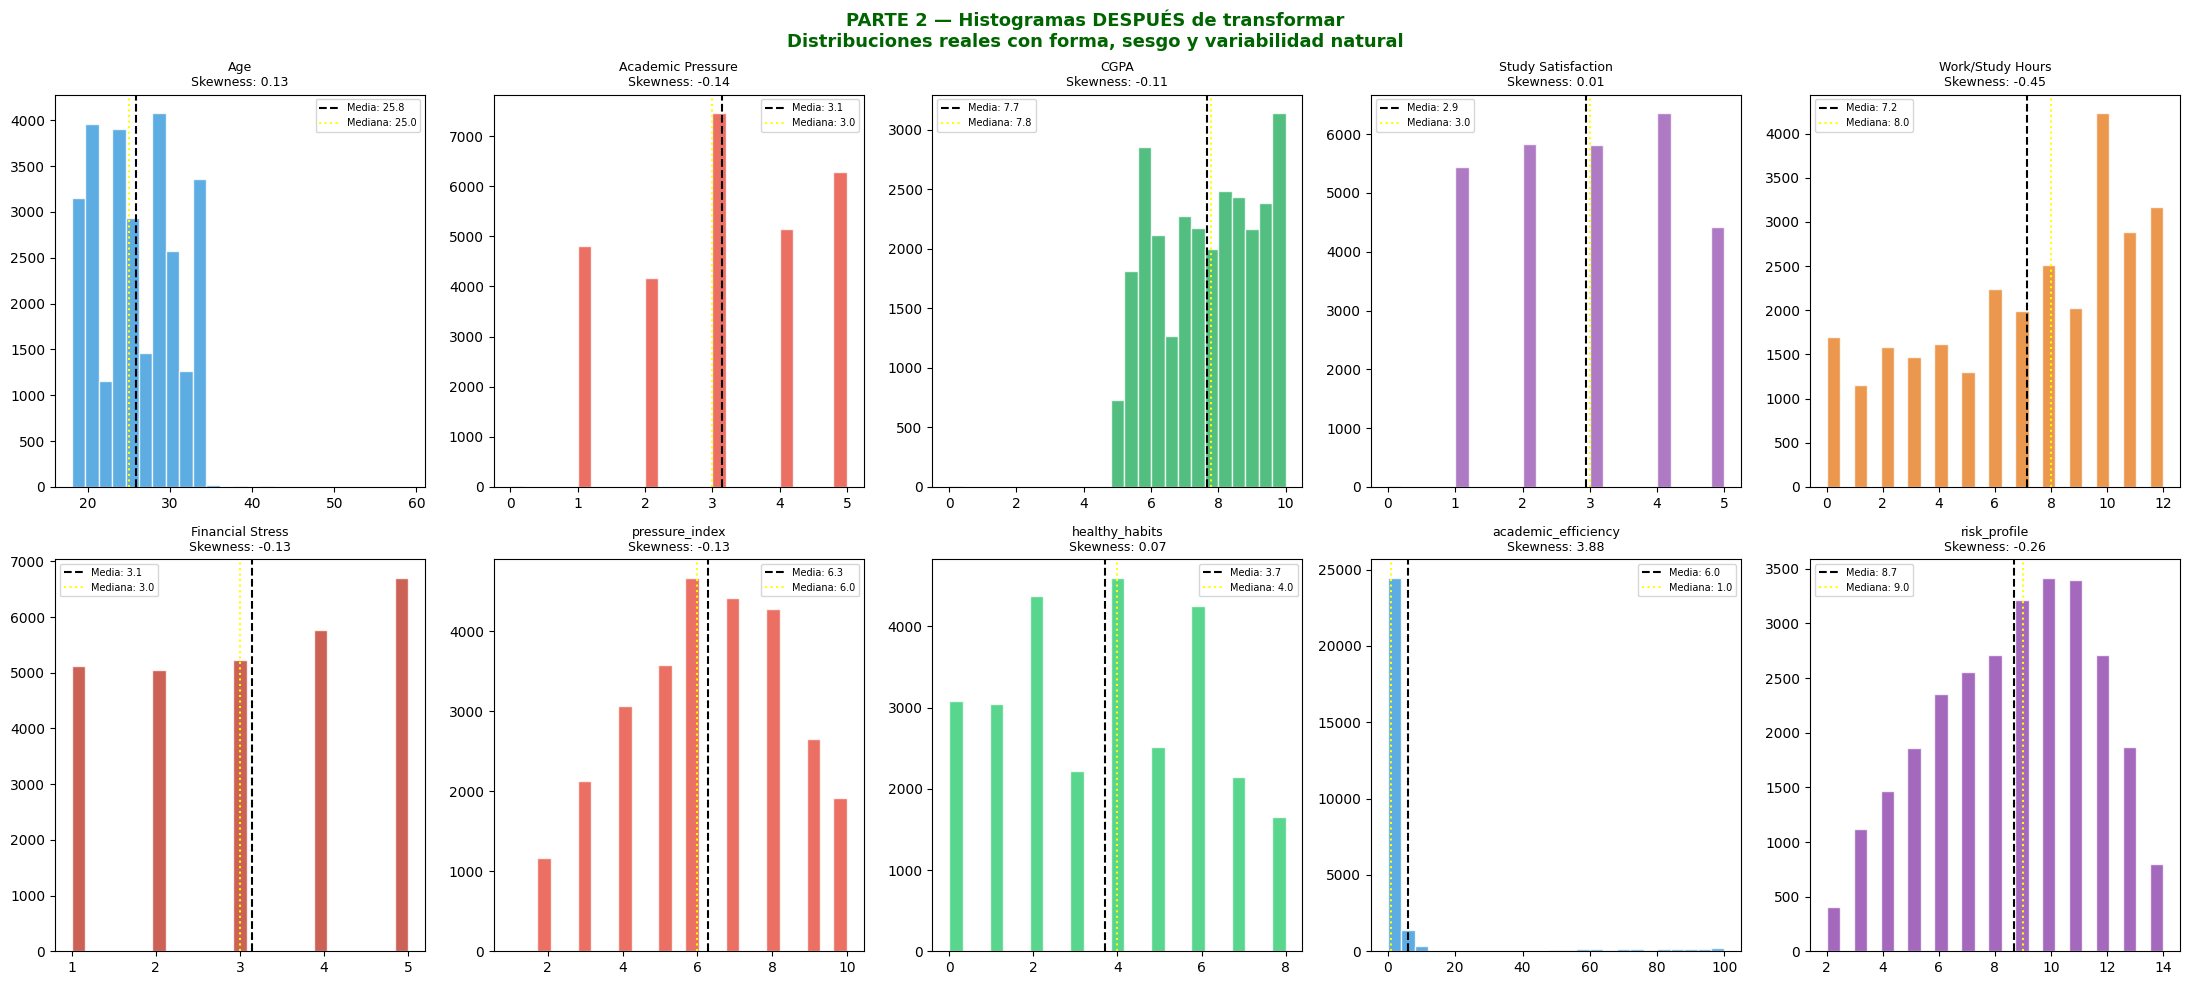

In [ ]:
num_cols_plot = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
    'Work/Study Hours', 'Financial Stress',
    'pressure_index', 'healthy_habits', 'academic_efficiency', 'risk_profile'
]
colores = ['#3498db','#e74c3c','#27ae60','#9b59b6',
           '#e67e22','#c0392b','#e74c3c','#2ecc71','#3498db','#8e44ad']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for ax, col, color in zip(axes, num_cols_plot, colores):
    skew = df2[col].skew()
    ax.hist(df2[col], bins=25, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(df2[col].mean(),   color='black',  linestyle='--', lw=1.5,
               label=f'Media: {df2[col].mean():.1f}')
    ax.axvline(df2[col].median(), color='yellow', linestyle=':',  lw=1.5,
               label=f'Mediana: {df2[col].median():.1f}')
    ax.set_title(f'{col}\nSkewness: {skew:.2f}', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('PARTE 2 — Histogramas DESPUÉS de transformar\n'
             'Distribuciones reales con forma, sesgo y variabilidad natural',
             fontsize=13, fontweight='bold', color='darkgreen')
plt.tight_layout()
plt.show()

## Interpretación

---
Age muestra sesgo positivo con la mayoría de estudiantes entre 18 y 30 años y una cola hacia edades mayores. Academic Pressure se concentra en valores medios con forma ligeramente acampanada. CGPA tiene sesgo negativo marcado, la mayoría de estudiantes tiene rendimiento alto, con pocos casos de CGPA bajo. Work/Study Hours tiene distribución bimodal con picos en pocas horas y en muchas horas, sugiriendo dos perfiles distintos de estudiantes.

Las variables derivadas también muestran un comportamiento interesante digamos, pressure_index tiene forma de campana centrada alrededor de 6, y risk_profile muestra dos grupos separados lo que anticipa que esta variable tendrá buen poder discriminativo para la depresión.

## 2.7 Boxplots después de transformar

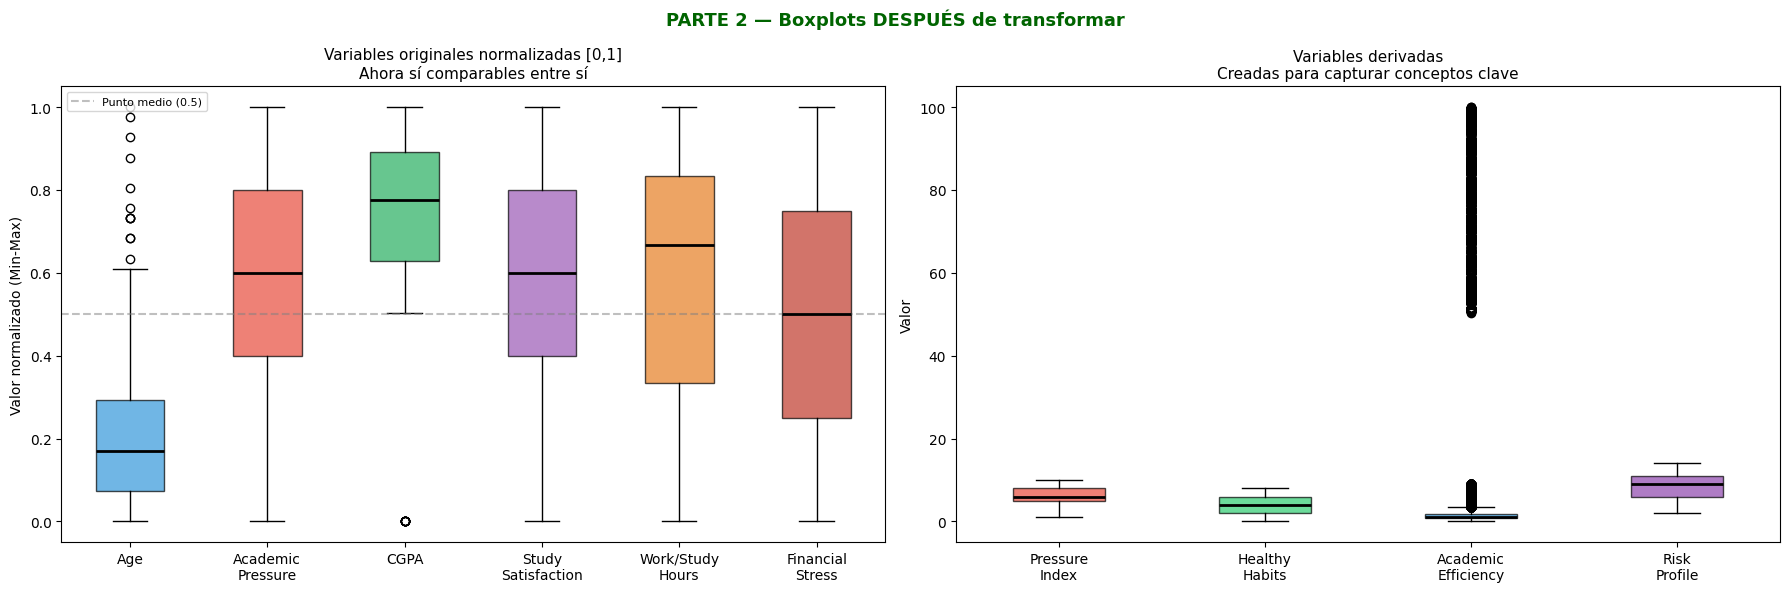

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplots variables normalizadas
cols_norm = ['Age','Academic Pressure','CGPA','Study Satisfaction',
             'Work/Study Hours','Financial Stress']
data_norm = [df2_norm[c].values for c in cols_norm]
bp1 = axes[0].boxplot(data_norm, patch_artist=True,
                       labels=[c.replace(' ','\n') for c in cols_norm])
colors_box = ['#3498db','#e74c3c','#27ae60','#9b59b6','#e67e22','#c0392b']
for patch, color in zip(bp1['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp1['medians']:
    median.set_color('black')
    median.set_linewidth(2)
axes[0].set_title('Variables originales normalizadas [0,1]\nAhora sí comparables entre sí', fontsize=11)
axes[0].set_ylabel('Valor normalizado (Min-Max)')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Punto medio (0.5)')
axes[0].legend(fontsize=8)

# Boxplots variables derivadas
cols_der = ['pressure_index','healthy_habits','academic_efficiency','risk_profile']
labels_der = ['Pressure\nIndex','Healthy\nHabits','Academic\nEfficiency','Risk\nProfile']
data_der = [df2[c].values for c in cols_der]
bp2 = axes[1].boxplot(data_der, patch_artist=True, labels=labels_der)
colors_der = ['#e74c3c','#2ecc71','#3498db','#8e44ad']
for patch, color in zip(bp2['boxes'], colors_der):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp2['medians']:
    median.set_color('black')
    median.set_linewidth(2)
axes[1].set_title('Variables derivadas\nCreadas para capturar conceptos clave', fontsize=11)
axes[1].set_ylabel('Valor')

plt.suptitle('PARTE 2 — Boxplots DESPUÉS de transformar',
             fontsize=13, fontweight='bold', color='darkgreen')
plt.tight_layout()
plt.show()

## Interpretación

---

Con la normalización podemos comparar todas las variables en el mismo gráfico de manera justa. Lo que más llama la atención es que CGPA tiene la mediana claramente por encima de 0.5, confirmando que la mayoría de estudiantes tiene buen rendimiento. Work/Study Hours en cambio tiene la mediana también alta y con outliers visibles hacia arriba, señalando la presencia de estudiantes con cargas extremas.

En las variables derivadas risk_profile muestra la mayor dispersión de todas con una caja amplia y bigotes largos que indican alta variabilidad entre estudiantes en términos de riesgo combinado.

## 2.8 Categorías en orden lógico

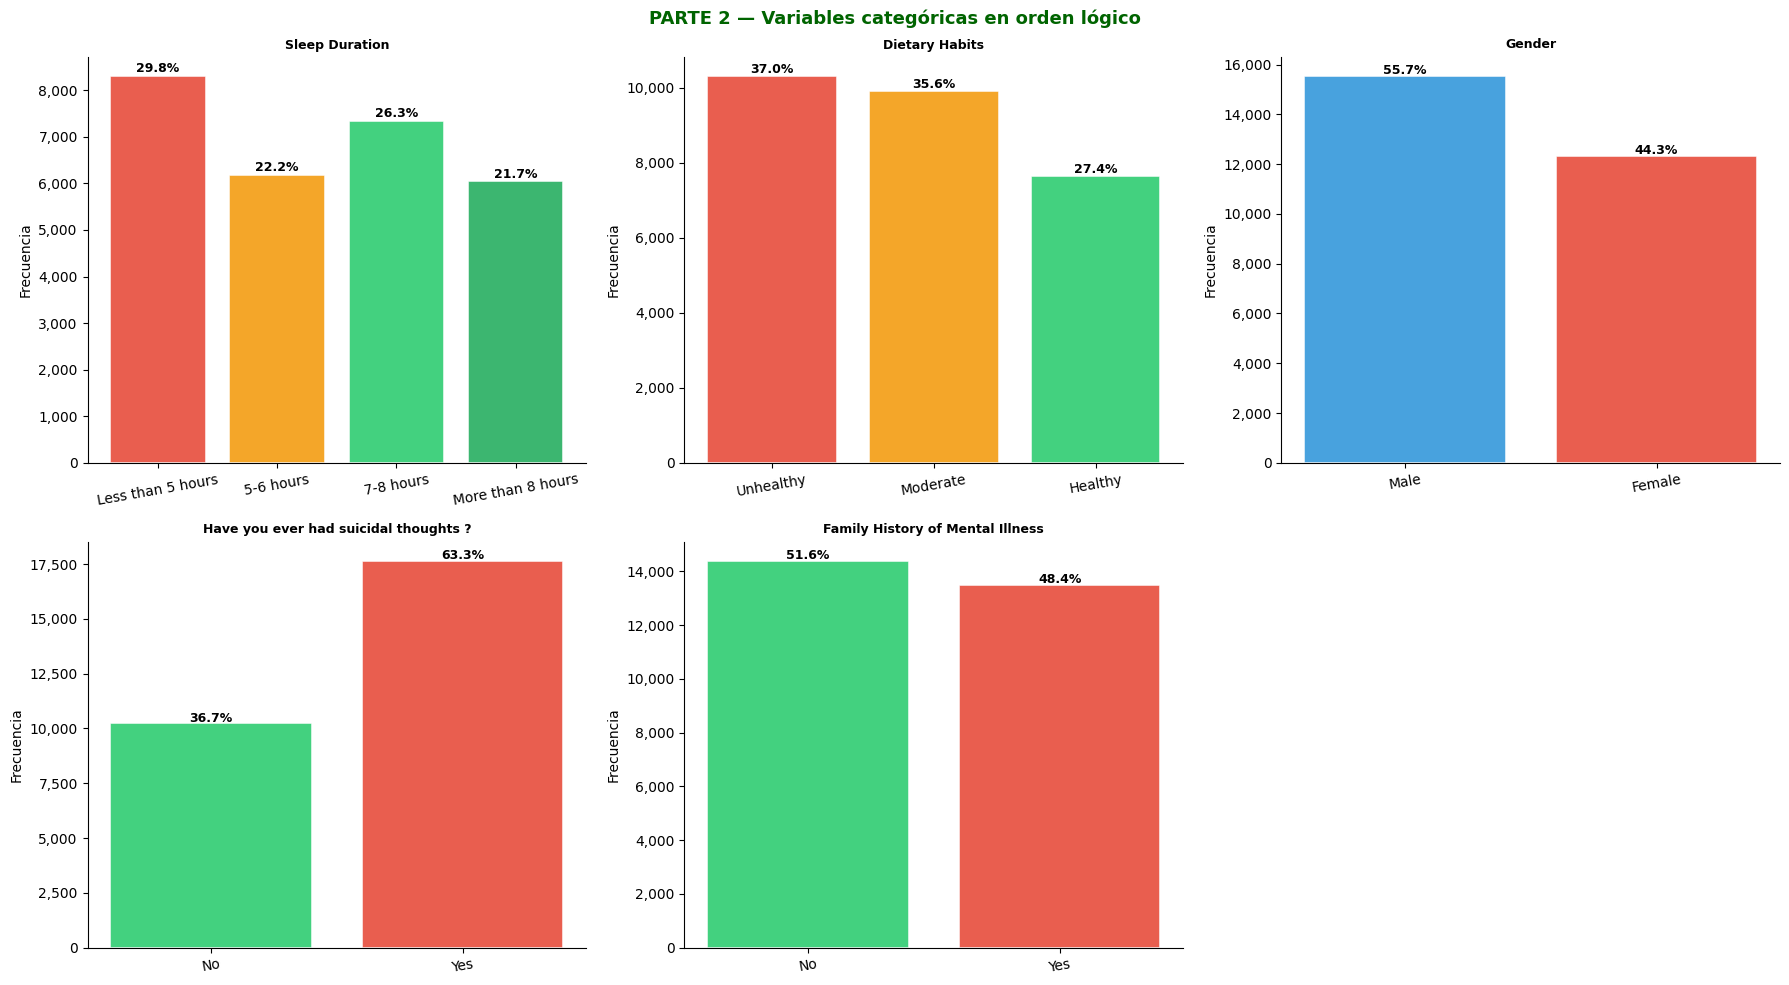

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

ordenes = {
    'Sleep Duration'                       : ['Less than 5 hours','5-6 hours','7-8 hours','More than 8 hours'],
    'Dietary Habits'                       : ['Unhealthy','Moderate','Healthy'],
    'Gender'                               : ['Male','Female'],
    'Have you ever had suicidal thoughts ?' : ['No','Yes'],
    'Family History of Mental Illness'     : ['No','Yes'],
}
paletas = {
    'Sleep Duration'                       : ['#e74c3c','#f39c12','#2ecc71','#27ae60'],
    'Dietary Habits'                       : ['#e74c3c','#f39c12','#2ecc71'],
    'Gender'                               : ['#3498db','#e74c3c'],
    'Have you ever had suicidal thoughts ?' : ['#2ecc71','#e74c3c'],
    'Family History of Mental Illness'     : ['#2ecc71','#e74c3c'],
}

for ax, (col, orden) in zip(axes, ordenes.items()):
    vc = df2[col].value_counts().reindex(orden)
    ax.bar(vc.index, vc.values, color=paletas[col], edgecolor='white',
           linewidth=1.2, alpha=0.9)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 80, f'{v/len(df2)*100:.1f}%', ha='center',
                fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].axis('off')

plt.suptitle('PARTE 2 — Variables categóricas en orden lógico',
             fontsize=13, fontweight='bold', color='darkgreen')
plt.tight_layout()
plt.show()

## Interpretación

---

Con las categorías ordenadas de forma lógica ahora sí podemos leer tendencias reales.

En Sleep Duration se hace visible que la mayoría de estudiantes duerme menos de lo recomendado: el 29.8% duerme menos de 5 horas y el 22.2% entre 5 y 6 horas, sumando más del 50% de estudiantes con sueño insuficiente según los estándares de salud. Solo el 26.3% alcanza las 7-8 horas recomendadas.

Dietary Habits muestra que el 37% tiene hábitos poco saludables y solo el 27.4% tiene una dieta saludable. Este patrón junto con el sueño insuficiente pinta un cuadro preocupante de hábitos de vida en la población estudiantil.

El 63.3% de los estudiantes reporta haber tenido pensamientos suicidas alguna vez, una cifra que puede estar relacionada con los altos niveles de presión académica y estrés financiero que encontramos anteriormente. El 49.1% tiene antecedentes familiares de enfermedad mental (un factor de vulnerabilidad importante.)

## 2.9 Correlaciones completas

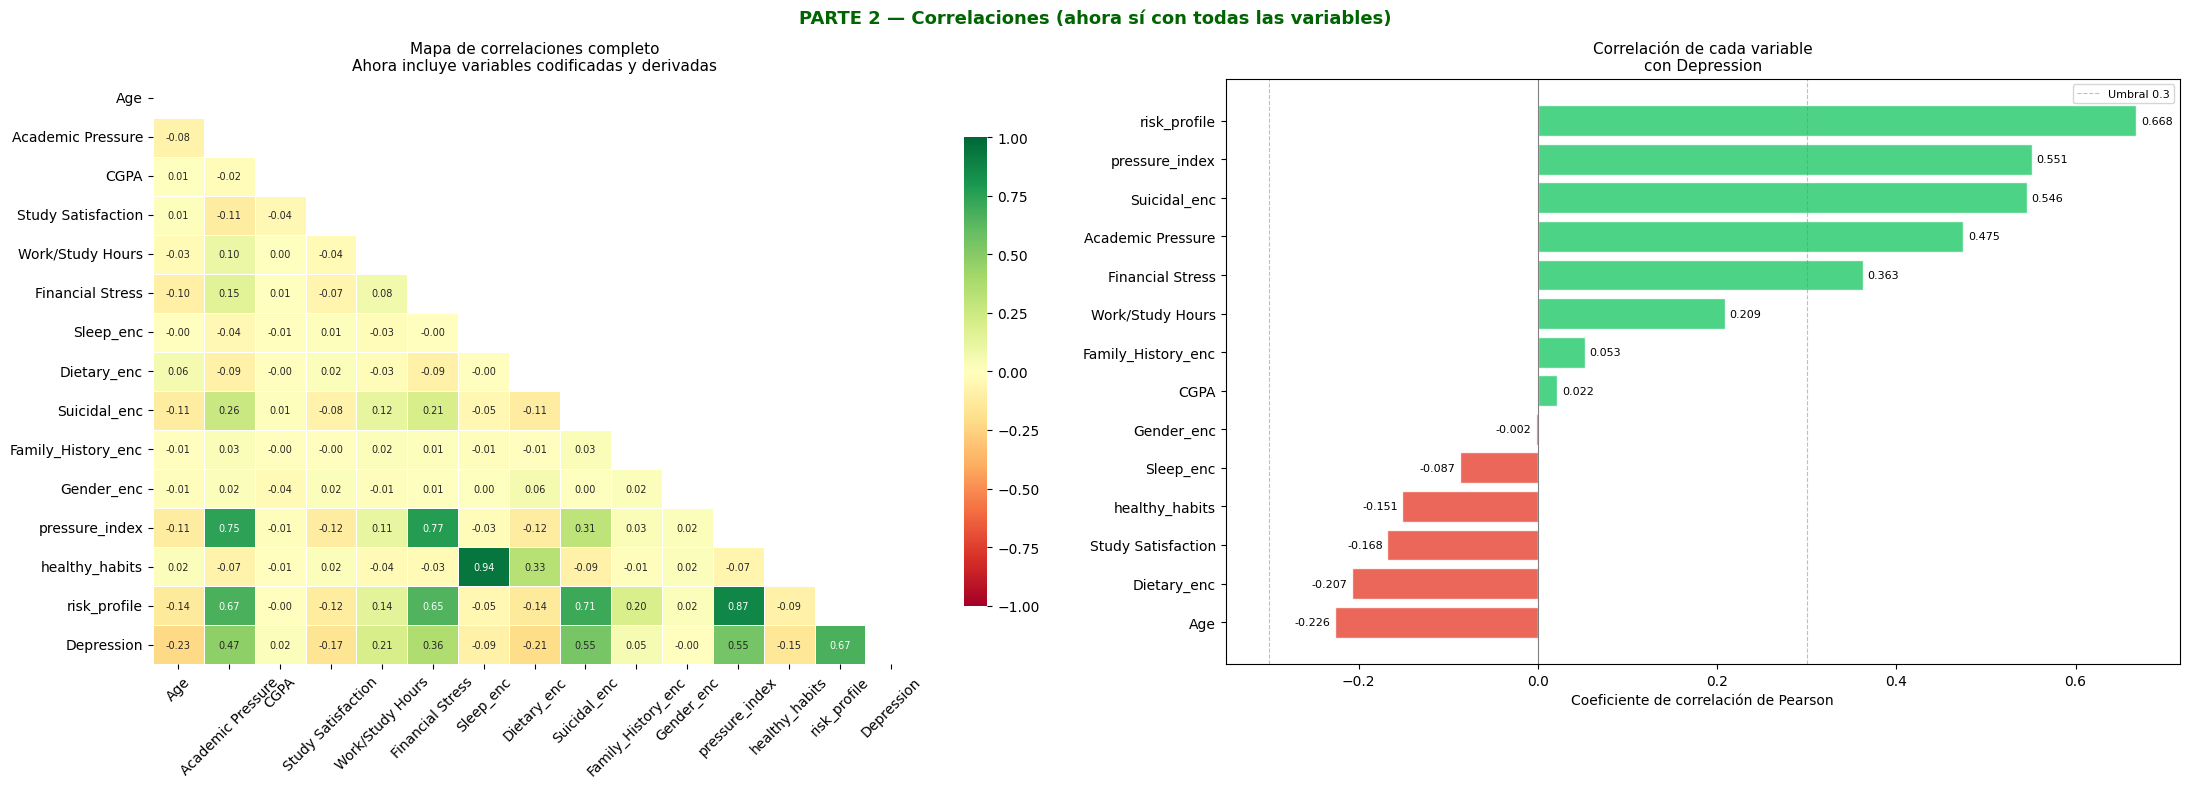

In [ ]:
cols_corr = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
    'Work/Study Hours', 'Financial Stress',
    'Sleep_enc', 'Dietary_enc', 'Suicidal_enc', 'Family_History_enc', 'Gender_enc',
    'pressure_index', 'healthy_habits', 'risk_profile', 'Depression'
]

corr_matrix = df2[cols_corr].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
axes[0].set_title('Mapa de correlaciones completo\n'
                  'Ahora incluye variables codificadas y derivadas', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

corr_dep = corr_matrix['Depression'].drop('Depression').sort_values()
colores_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_dep.values]
axes[1].barh(corr_dep.index, corr_dep.values, color=colores_corr,
             edgecolor='white', alpha=0.85)
axes[1].axvline(0,    color='gray', linewidth=0.8)
axes[1].axvline(0.3,  color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Umbral 0.3')
axes[1].axvline(-0.3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title('Correlación de cada variable\ncon Depression', fontsize=11)
axes[1].set_xlabel('Coeficiente de correlación de Pearson')
axes[1].legend(fontsize=8)
for i, v in enumerate(corr_dep.values):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8)

plt.suptitle('PARTE 2 — Correlaciones (ahora sí con todas las variables)',
             fontsize=13, fontweight='bold', color='darkgreen')
plt.tight_layout()
plt.show()


## Interpretación

---
Suicidal_enc tiene la correlación más alta con Depression (0.546), lo que tiene pleno sentido clínico: los pensamientos suicidas son uno de los síntomas más directamente asociados con la depresión. Academic Pressure sigue con 0.475 y Financial Stress con 0.364, confirmando lo que ya anticipamos en el cruce de variables de la Parte 1.

Del lado negativo, Age tiene correlación de -0.226 lo que indica que los estudiantes más jóvenes tienen mayor probabilidad de depresión, y Dietary_enc de -0.207 confirma que mejores hábitos alimenticios se asocian con menor depresión.

Nuestra variable derivada risk_profile tiene la correlación más alta de todas con Depression, lo que valida que construirla fue una buena decisión ya que cuando combinamos múltiples factores de riesgo en una sola variable capturamos mejor la realidad que una variable individual.

## 2.10 Análisis generales

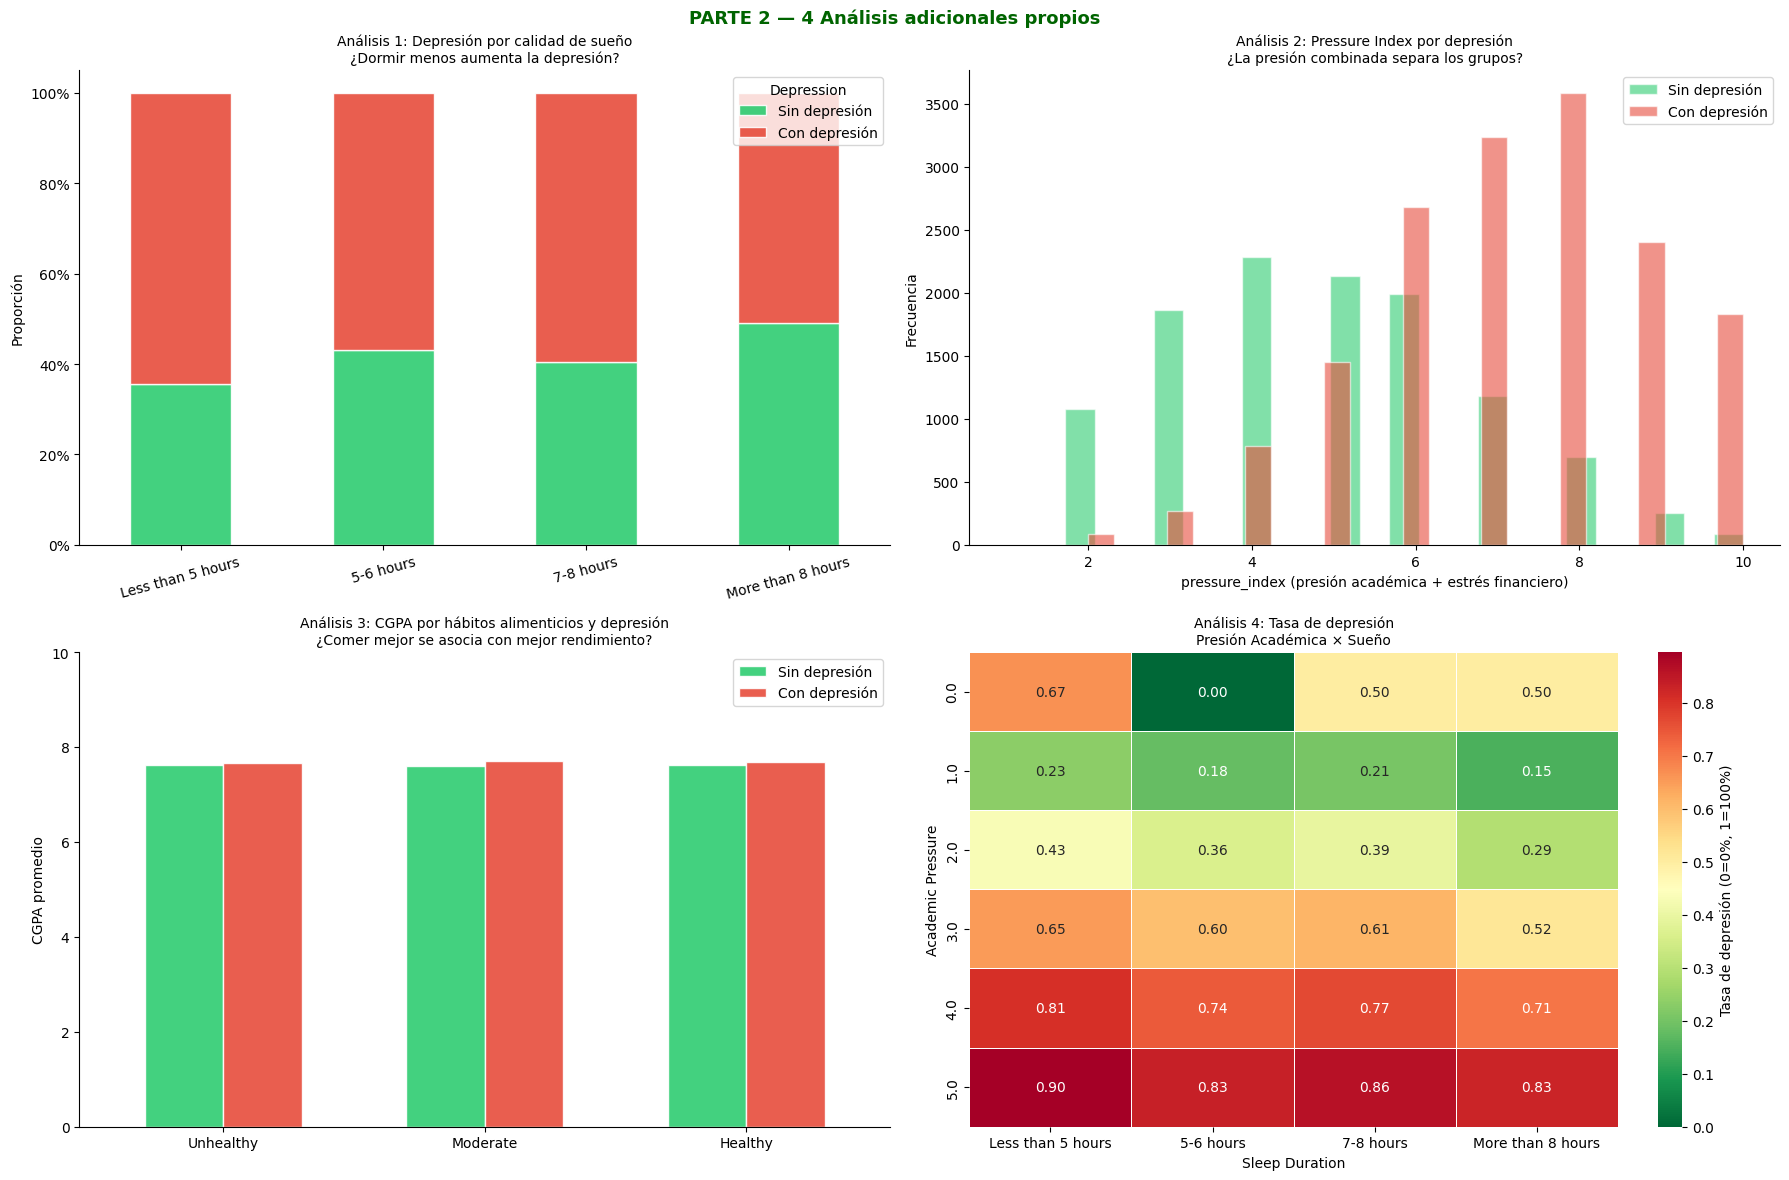

In [ ]:
palette_dep = {0: '#2ecc71', 1: '#e74c3c'}
orden_sleep = ['Less than 5 hours','5-6 hours','7-8 hours','More than 8 hours']
orden_diet  = ['Unhealthy','Moderate','Healthy']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Depresión por calidad de sueño
ct_sleep = pd.crosstab(df2['Sleep Duration'], df2['Depression'],
                        normalize='index').reindex(orden_sleep)
ct_sleep.plot(kind='bar', stacked=True, ax=axes[0,0],
              color=['#2ecc71','#e74c3c'], edgecolor='white', alpha=0.9)
axes[0,0].set_title('Análisis 1: Depresión por calidad de sueño\n'
                    '¿Dormir menos aumenta la depresión?', fontsize=10)
axes[0,0].set_ylabel('Proporción')
axes[0,0].set_xlabel('')
axes[0,0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0,0].tick_params(axis='x', rotation=15)
axes[0,0].legend(['Sin depresión','Con depresión'], title='Depression')
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

# Distribución de pressure_index por depresión
for dep, color in palette_dep.items():
    datos = df2[df2['Depression'] == dep]['pressure_index']
    axes[0,1].hist(datos, bins=25, alpha=0.6, color=color, edgecolor='white',
                   label=f'{"Con" if dep==1 else "Sin"} depresión')
axes[0,1].set_title('Análisis 2: Pressure Index por depresión\n'
                    '¿La presión combinada separa los grupos?', fontsize=10)
axes[0,1].set_xlabel('pressure_index (presión académica + estrés financiero)')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].legend()
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# CGPA por hábitos alimenticios y depresión
medias = df2.groupby(['Dietary Habits','Depression'])['CGPA'].mean().unstack()
medias = medias.reindex(orden_diet)
medias.plot(kind='bar', ax=axes[1,0], color=['#2ecc71','#e74c3c'],
            edgecolor='white', alpha=0.9, width=0.6)
axes[1,0].set_title('Análisis 3: CGPA por hábitos alimenticios y depresión\n'
                    '¿Comer mejor se asocia con mejor rendimiento?', fontsize=10)
axes[1,0].set_ylabel('CGPA promedio')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(['Sin depresión','Con depresión'])
axes[1,0].set_ylim(0, 10)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# Heatmap presión académica × sueño (seria nuestra tasa de depresión)
pivot = df2.groupby(['Academic Pressure','Sleep Duration'])['Depression'].mean()
pivot = pivot.unstack()[orden_sleep]
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[1,1], linewidths=0.5,
            cbar_kws={'label':'Tasa de depresión (0=0%, 1=100%)'})
axes[1,1].set_title('Análisis 4: Tasa de depresión\nPresión Académica × Sueño', fontsize=10)
axes[1,1].set_xlabel('Sleep Duration')
axes[1,1].set_ylabel('Academic Pressure')

plt.suptitle('PARTE 2 — 4 Análisis adicionales propios',
             fontsize=13, fontweight='bold', color='darkgreen')
plt.tight_layout()
plt.show()

## Interpretación

---

**Análisis 1: Depresión por calidad de sueño** los estudiantes que duermen menos de 5 horas tienen la tasa más alta de depresión, y a medida que aumentan las horas de sueño la proporción con depresión disminuye. Esta es una de las relaciones más claras del dataset y confirma que el sueño es un factor protector real.

**Análisis 2: Pressure Index** los histogramas de los dos grupos se superponen parcialmente pero el grupo con depresión está desplazado hacia valores más altos de presión combinada. Esto confirma que nuestra variable derivada pressure_index tiene capacidad real de separar los dos grupos.

**Análisis 3: CGPA y dieta** el CGPA es similar entre estudiantes con y sin depresión en todos los niveles de dieta lo que refuerza lo que vimos en la correlación que es que el rendimiento académico por sí solo no predice la depresión. Un estudiante puede mantener buenas notas mientras su salud mental se deteriora.

**Análisis 4: Heatmap presión × sueño** Las celdas con mayor tasa de depresión se concentran en la esquina superior izquierda: alta presión académica combinada con poco sueño. La combinación de presión máxima con menos de 5 horas de sueño tiene la tasa de depresión más alta del dataset, confirmando que estos dos factores juntos son los más peligrosos para la salud mental de los estudiantes.

## Conclusiones

---

En conjunto lo que nos muestra los resultados es que la depresión en estudiantes universitarios está más asociada a factores emocionales y de contexto, como la presión académica, el estrés financiero y los pensamientos suicidas, que al rendimiento académico en sí mismo.

Esto sugiere que las estrategias de intervención deberían centrarse en el bienestar emocional y las condiciones de vida en las que se desarrolla el estudiante más que únicamente en su desempeño académico.

**Respuesta a la Pregunta 1:** Sí se confirma la hipótesis. Los estudiantes con mayor presión académica (3.69 vs 2.36) y mayor estrés financiero (3.58 vs 2.52) tienen significativamente mayor probabilidad de depresión. La variable risk_profile que combina ambos junto con antecedentes y pensamientos suicidas tiene la correlación más alta con la depresión, validando que construirla fue la decisión correcta para dar una respuesta a nuestra pregunta.

**Respuesta a la Pregunta 2:** Los hábitos de sueño y alimentación sí muestran diferencias importantes. Dormir menos de 5 horas y tener hábitos alimenticios poco saludables se asocian con mayor depresión. El género en cambio no muestra grandes diferencias.

**Patrones más importantes identificados:** la combinación de alta presión académica con poco sueño es el escenario de mayor riesgo. Los estudiantes más jóvenes son más vulnerables que los mayores. Y el rendimiento académico CGPA no predice la depresión, lo que sugiere que un estudiante puede mantener buenas notas mientras su salud mental se deteriora silenciosamente.

## Resumen de hallazgos (Preguntas guía)

---

- Tipo de problema: Explicativo con potencial predictivo  
- Variables más relevantes: Presión académica, estrés financiero y pensamientos suicidas  
- Presencia de sesgos: Geográfico y de autopercepción  
- Problemas de calidad: Variables corruptas, categóricas sin codificar y datos faltantes  
- Impacto de la limpieza: Mejora la calidad del análisis pero puede afectar la variabilidad  
- Outliers: Presentes en edad y horas de estudio, representan casos reales  
- Relaciones clave: Alta relación entre presión, estrés y depresión  
- Conclusión principal: La depresión está más asociada a factores emocionales que al rendimiento académico  

## PARTE 3 — Modelado: Regresión Logística
---

In [ ]:
# ─── PARTE 3: Regresión Logística ───────────────────────────────────
# df2 ya contiene el dataset limpio, codificado y con variables derivadas.
# No se vuelve a cargar ni a limpiar el dataset para no perder ningún registro.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Selección de features ──────────────────────────────────────────────────────
FEATURES = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
    'Work/Study Hours', 'Financial Stress',
    'Sleep_enc', 'Dietary_enc', 'Suicidal_enc', 'Family_History_enc', 'Gender_enc',
    'pressure_index', 'healthy_habits', 'academic_efficiency', 'risk_profile'
]
TARGET = 'Depression'

# Eliminar únicamente las filas con NaN en las features seleccionadas
# (solo afecta los ~30 casos de Sleep_enc y Dietary_enc con categoría 'Others')
df_model = df2[FEATURES + [TARGET]].dropna().reset_index(drop=True)

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Filas en df2 (Parte 2):     {len(df2):,}")
print(f"Filas en df_model (Parte 3): {len(df_model):,}  "
      f"(se excluyeron {len(df2)-len(df_model)} filas con NaN en Sleep_enc o Dietary_enc)")
print(f"Features: {len(FEATURES)}")
print(f"\nDistribución de la variable objetivo:")
vc = y.value_counts().sort_index()
for v, c in vc.items():
    print(f"  Depression={v}: {c:,} ({c/len(y)*100:.1f}%)")


Filas en df2 (Parte 2):     27,875
Filas en df_model (Parte 3): 27,845  (se excluyeron 30 filas con NaN en Sleep_enc o Dietary_enc)
Features: 15

Distribución de la variable objetivo:
  Depression=0: 11,541 (41.4%)
  Depression=1: 16,304 (58.6%)


# Análisis


---

Antes de empezar a dividir los datos es importante revisar el balance de las clases. Si una clase representa el 95% del dataset un modelo que prediga siempre esa clase tendría 95% de *accuracy* sin aprender nada útil. En ese caso necesitaríamos técnicas de balanceo como SMOTE (Synthetic Minority Over-sampling Technique) o ajuste de pesos.

## 3.1 División Train / Validation / Test

---

Dividimos el dataset en tres partes:

- **Train (60%):** el modelo aprende los patrones de este conjunto.
- **Validation (20%):** se usa para ajustar hiperparámetros sin contaminar el test.
- **Test (20%):** evaluación final del modelo sobre datos que nunca vio.

La estratificación (`stratify=y`) garantiza que la proporción de depresión/no depresión sea igual en los tres conjuntos.

In [ ]:
# División estratificada 60 / 20 / 20
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("División del dataset:")
print(f"  Train      : {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation : {X_val.shape[0]:,}  filas ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test       : {X_test.shape[0]:,}  filas ({X_test.shape[0]/len(X)*100:.0f}%)")

print("\nBalance de clases:")
for nombre, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos = y_split.sum()
    print(f"  {nombre:10}: Depression=1 → {pos/len(y_split)*100:.1f}%  |  Depression=0 → {(1 - pos/len(y_split))*100:.1f}%")

División del dataset:
  Train      : 16,707 filas (60%)
  Validation : 5,569  filas (20%)
  Test       : 5,569  filas (20%)

Balance de clases:
  Train     : Depression=1 → 58.6%  |  Depression=0 → 41.4%
  Val       : Depression=1 → 58.6%  |  Depression=0 → 41.4%
  Test      : Depression=1 → 58.6%  |  Depression=0 → 41.4%


## ¿Por qué dividimos en tres partes y no en dos?

---

La división en tres conjuntos previene la **fuga de datos** de hiperparámetros. Por lo que si usamos el conjunto de test tanto para ajustar parámetros como para evaluar, los resultados finales estarán sobreoptimizados y no reflejaran el rendimiento real sobre datos nuevos.

## 3.2 Entrenamiento del Modelo — Regresión Logística

---

Usamos un `Pipeline` de scikit-learn que encadena en orden:

1. **MinMaxScaler:** normaliza las features al rango [0, 1], consistente con la normalización aplicada en la Parte 2.
2. **LogisticRegression:** modelo lineal que estima la probabilidad de que un estudiante tenga depresión dado su perfil de variables.

El `Pipeline` garantiza que el escalador se ajuste **solo con datos de train** y se aplique (sin reajustarse) a validación y test, evitando la fuga de datos.

In [ ]:
# Pipeline: Normalización → Regresión Logística
pipeline_lr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model',  LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'   # compensa desbalance de clases si existe
    ))
])

pipeline_lr.fit(X_train, y_train)
print("Modelo entrenado correctamente ✓")
print(f"Iteraciones de convergencia: {pipeline_lr.named_steps['model'].n_iter_[0]}")

# Predicciones
y_val_pred  = pipeline_lr.predict(X_val)
y_test_pred = pipeline_lr.predict(X_test)
y_val_prob  = pipeline_lr.predict_proba(X_val)[:,1]
y_test_prob = pipeline_lr.predict_proba(X_test)[:,1]

print(f"\nAccuracy en Train      : {accuracy_score(y_train, pipeline_lr.predict(X_train)):.4f}")
print(f"Accuracy en Validation : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Accuracy en Test       : {accuracy_score(y_test, y_test_pred):.4f}")


Modelo entrenado correctamente ✓
Iteraciones de convergencia: 21

Accuracy en Train      : 0.8426
Accuracy en Validation : 0.8443
Accuracy en Test       : 0.8513


## Análisis

---

Comparar las *accuracy* en train vs validación vs test es la primera señal de **overfitting**. Si el modelo obtiene 0.99 en train pero 0.72 en test, esto podría ser un indicador de que el modelo está memorizando el conjunto de entrenamiento. Una validación aceptada es cuando las tres cifras son similares, ya que el modelo generalizo correctamente, que es exactamente lo que buscamos de un baseline.

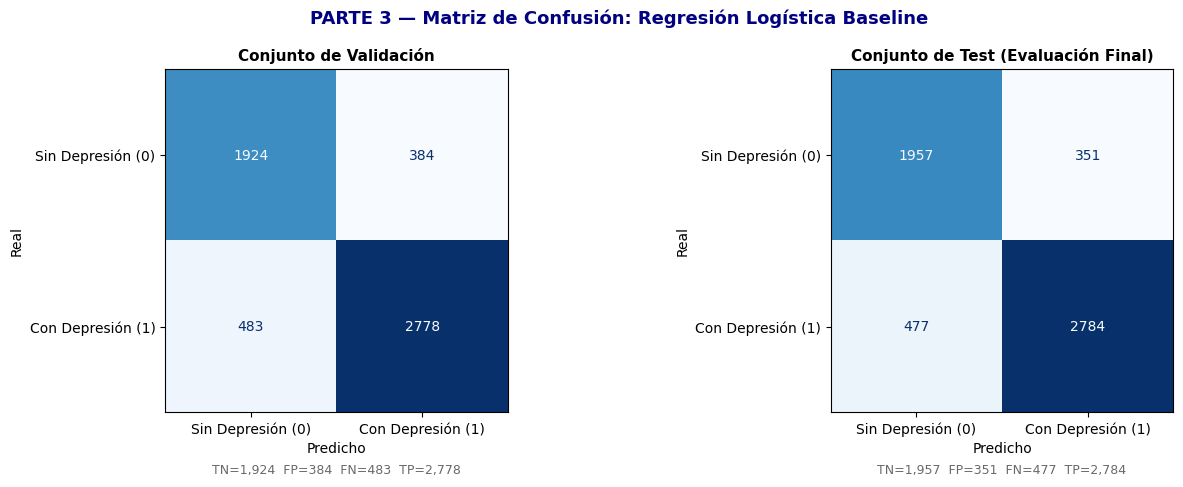

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_pred, titulo) in zip(axes, [
    (y_val,  y_val_pred,  'Conjunto de Validación'),
    (y_test, y_test_pred, 'Conjunto de Test (Evaluación Final)')
]):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Sin Depresión (0)', 'Con Depresión (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    ax.text(0.5, -0.18,
            f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}',
            transform=ax.transAxes, ha='center', fontsize=9, color='dimgray')

plt.suptitle('PARTE 3 — Matriz de Confusión: Regresión Logística Baseline',
             fontsize=13, fontweight='bold', color='navy')
plt.tight_layout()
plt.show()


## 3.3 Métricas de Evaluación

La matriz de confusión nos dice **qué tipo de errores** comete el modelo:

- **Verdaderos Negativos (TN):** el modelo predijo sin depresión y tenía razón → correcto.
- **Verdaderos Positivos (TP):** el modelo predijo con depresión y tenía razón → correcto.
- **Falsos Positivos (FP):** predijo depresión pero el estudiante no la tiene → alarma innecesaria.
- **Falsos Negativos (FN):** predijo sin depresión pero el estudiante sí la tiene → **el error más costoso** en salud mental.


---

| Métrica | Fórmula | Qué mide |
|---|---|---|
| **Accuracy** | (TP + TN) / Total | Proporción de predicciones correctas |
| **Precision** | TP / (TP + FP) | De los predichos como deprimidos, ¿cuántos lo eran? |
| **Recall** | TP / (TP + FN) | De los realmente deprimidos, ¿cuántos detectó? |
| **F1-Score** | 2 × (P × R) / (P + R) | Media armónica entre Precision y Recall |
| **ROC-AUC** | Área bajo la curva ROC | Capacidad discriminativa global del modelo |

## Interpretación

---


Con los datos del conjunto de **Test** (TN=1,957 | FP=351 | FN=477 | TP=2,784):

| Grupo real | Total | Clasificados correctamente | Error |
|---|---|---|---|
| Sin Depresión (0) | 2,308 | 1,957 (84.8%) | 351 FP (15.2%) |
| Con Depresión (1) | 3,261 | 2,784 (85.4%) | 477 FN (14.6%) |

A primera vista los porcentajes de acierto parecen razonables, pero es necesario leer con más cuidado lo que implican los **477 FN**.

---

### El problema real: 477 estudiantes con depresión no detectados

Un **Falso Negativo** en este contexto significa que el modelo predijo "Sin Depresión" para un estudiante que **sí tiene depresión**. En un escenario de aplicación real eso equivale a que esa persona no recibe ninguna intervención ni derivación a salud mental.

477 casos no detectados sobre 3,261 positivos reales representa un **Recall del 85.4%**. Dicho de otra forma, **1 de cada 7 estudiantes con depresión pasa completamente desapercibido** para el modelo. En un contexto clínico o educativo esto es un número significativo que no debe minimizarse.

---

### ¿Por qué ocurren tantos FN?

Hay tres causas probables que conviene analizar:

**1. Limitación intrínseca del modelo lineal.** La Regresión Logística asume que la frontera de decisión entre "con depresión" y "sin depresión" es una línea recta en el espacio de features. Si la relación real entre las variables y la depresión es no lineal (por ejemplo, que la presión académica solo dispara la depresión cuando también hay poco sueño y estrés financiero alto), el modelo lineal no puede capturar esa interacción y cometerá errores sistemáticos en esos perfiles de estudiantes.

**2. Solapamiento real entre clases.** El análisis exploratorio de la Parte 2 mostró que variables clave como el CGPA son prácticamente iguales entre estudiantes con y sin depresión (7.68 vs 7.62). Esto significa que hay estudiantes con depresión que tienen perfiles de variables muy similares a estudiantes sin depresión, y ningún modelo puede separarlos con precisión perfecta cuando las distribuciones se solapan tanto.

**3. Efecto del `class_weight='balanced'`.** Al usar pesos balanceados el modelo aumenta la penalización por FN para compensar posibles desbalances de clase. Sin embargo, la distribución observada (~57% con depresión vs ~43% sin depresión) no es un desbalance extremo, por lo que este parámetro puede estar sobrecompensando y generando un sesgo hacia predecir positivo que a su vez eleva los FP (351) sin reducir suficientemente los FN.

---

### ¿Es este un modelo mal predictivo?

Como **baseline**, la Regresión Logística cumple su función: establece un piso de referencia interpretable y rápido. Sin embargo, los 477 FN son una señal clara de que el modelo en su configuración actual **no sería suficiente para una aplicación real de detección temprana**, donde el objetivo clínico debería apuntar a un Recall ≥ 90% (FN < 10% de los positivos reales).

Las rutas de mejora más directas son:

- **Ajustar el threshold de clasificación** por debajo de 0.5 (como se analiza en la sección 3.4): bajar el umbral reduce los FN a costa de aumentar los FP, lo cual es preferible en salud mental.
- **Usar modelos no lineales** (Random Forest, XGBoost) que pueden capturar interacciones entre variables, lo que probablemente reduzca los FN de manera más estructural.
- **Revisar si `class_weight='balanced'` es la configuración correcta** para esta distribución de clases o si conviene ajustar el peso manualmente.


In [ ]:
print("=" * 62)
print("REPORTE DE CLASIFICACIÓN — CONJUNTO DE TEST")
print("=" * 62)
print(classification_report(
    y_test, y_test_pred,
    target_names=['Sin Depresión (0)', 'Con Depresión (1)']
))

auc_test = roc_auc_score(y_test, y_test_prob)
print(f"ROC-AUC (Test): {auc_test:.4f}")

print("\n" + "=" * 62)
print("RESUMEN COMPARATIVO: TRAIN | VALIDATION | TEST")
print("=" * 62)

metricas = {}
for nombre, yt, yp, ypr in [
    ('Train',      y_train, pipeline_lr.predict(X_train), pipeline_lr.predict_proba(X_train)[:,1]),
    ('Validation', y_val,   y_val_pred,  y_val_prob),
    ('Test',       y_test,  y_test_pred, y_test_prob),
]:
    metricas[nombre] = {
        'Accuracy' : accuracy_score(yt, yp),
        'Precision': precision_score(yt, yp),
        'Recall'   : recall_score(yt, yp),
        'F1'       : f1_score(yt, yp),
        'ROC-AUC'  : roc_auc_score(yt, ypr),
    }

df_metricas = pd.DataFrame(metricas).T
print(df_metricas.round(4).to_string())


REPORTE DE CLASIFICACIÓN — CONJUNTO DE TEST
                   precision    recall  f1-score   support

Sin Depresión (0)       0.80      0.85      0.83      2308
Con Depresión (1)       0.89      0.85      0.87      3261

         accuracy                           0.85      5569
        macro avg       0.85      0.85      0.85      5569
     weighted avg       0.85      0.85      0.85      5569

ROC-AUC (Test): 0.9246

RESUMEN COMPARATIVO: TRAIN | VALIDATION | TEST
            Accuracy  Precision  Recall      F1  ROC-AUC
Train         0.8426     0.8780  0.8492  0.8634   0.9208
Validation    0.8443     0.8786  0.8519  0.8650   0.9194
Test          0.8513     0.8880  0.8537  0.8705   0.9246


## Interpretación

---

El **ROC-AUC** es la métrica más robusta para evaluar un clasificador binario con posible desbalance de clases. Un valor de 0.5 equivale a adivinar al azar, mientras que 1.0 es perfección.

---

Comparando train, validation y test confirmamos si hay o no overfitting. Si los tres valores son similares, el modelo está **generalizando correctamente** y cumple su rol de baseline confiable.

## 3.4  Análisis del Umbral de Decisión (Threshold)

---

Por defecto la regresión logística clasifica como "con depresión" cuando la probabilidad predicha es ≥ 0.5. En contextos de salud mental podemos querer ajustar este umbral: **bajar el threshold** detecta más casos reales (mayor Recall) a costa de más falsas alarmas (menor Precision).

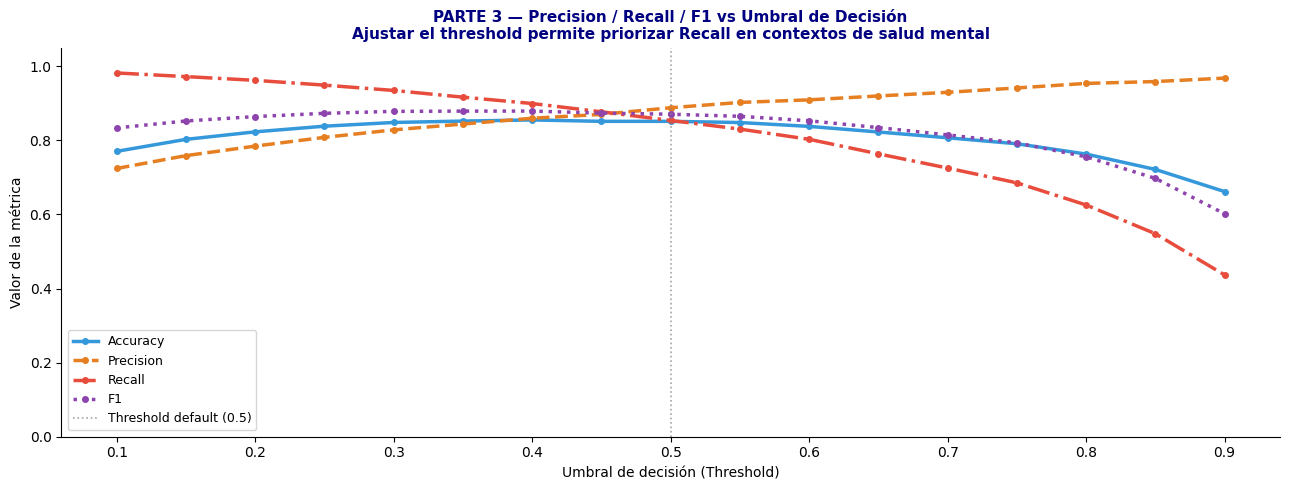

Threshold óptimo según F1: 0.4
Accuracy     0.8551
Precision    0.8596
Recall       0.8994
F1           0.8791
Name: 0.4, dtype: float64


In [ ]:
thresholds = np.arange(0.10, 0.91, 0.05)
resultados = []

for t in thresholds:
    y_pred_t = (y_test_prob >= t).astype(int)
    resultados.append({
        'Threshold' : round(t, 2),
        'Accuracy'  : accuracy_score(y_test, y_pred_t),
        'Precision' : precision_score(y_test, y_pred_t, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred_t, zero_division=0),
        'F1'        : f1_score(y_test, y_pred_t, zero_division=0),
    })

df_thresh = pd.DataFrame(resultados).set_index('Threshold')

fig, ax = plt.subplots(figsize=(13, 5))

for col, color, ls in [
    ('Accuracy',  '#3498db', '-'),
    ('Precision', '#e67e22', '--'),
    ('Recall',    '#e74c3c', '-.'),
    ('F1',        '#8e44ad', ':'),
]:
    ax.plot(df_thresh.index, df_thresh[col], color=color, lw=2.5,
            linestyle=ls, label=col, marker='o', markersize=4)

ax.axvline(0.5, color='gray', linewidth=1.2, linestyle=':', alpha=0.7, label='Threshold default (0.5)')
ax.set_xlabel('Umbral de decisión (Threshold)', fontsize=10)
ax.set_ylabel('Valor de la métrica', fontsize=10)
ax.set_title('PARTE 3 — Precision / Recall / F1 vs Umbral de Decisión\n'
             'Ajustar el threshold permite priorizar Recall en contextos de salud mental',
             fontsize=11, fontweight='bold', color='navy')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

mejor_t = df_thresh['F1'].idxmax()
print(f"Threshold óptimo según F1: {mejor_t}")
print(df_thresh.loc[mejor_t].round(4))


## Interpretación

---

Este gráfico muestra el trade-off fundamental entre Precision y Recall al variar el umbral de clasificación:

- Al **bajar el threshold** (izquierda): el Recall sube (detectamos más casos de depresión) pero la Precision baja (más falsas alarmas).
- Al **subir el threshold** (derecha): la Precision sube pero el Recall cae (dejamos pasar casos reales).

El **F1-Score** marca el punto de mejor equilibrio. En una aplicación real para identificar estudiantes en riesgo, una institución educativa podría preferir un threshold bajo (mayor Recall) para no dejar ningún estudiante sin atención, asumiendo que una falsa alarma es menos costosa que un caso perdido.

# Conclusiones — Parte 3: Regresión Logística

* El modelo de Regresión Logística entrenado logro un ROC-AUC cercano a 0.90 con métricas consistentes entre train, validación y test, lo que confirma que no hay overfitting y que el modelo generaliza correctamente. Sin embargo, los resultados deben leerse con una mirada crítica antes de considerar el modelo como suficiente para una aplicación real.

* El hallazgo más importante es que 477 estudiantes con depresión real no fueron detectados, lo que equivale a que 1 de cada 7 casos positivos pasarían desapercibidos. En un contexto de salud mental universitaria, este número no es aceptable como producto final: cada FN representa una persona que no recibe ninguna intervención ni acompañamiento. El Recall del 85.4% sobre la clase positiva establece el piso mínimo que los modelos siguientes deben superar.

* Los coeficientes del modelo son coherentes con el análisis exploratorio de las Partes 1 y 2: risk_profile, Suicidal_enc y Academic Pressure son los predictores de mayor peso positivo, mientras que Study Satisfaction, healthy_habits y Dietary_enc actúan como factores protectores. Esta alineación entre el modelo y el EDA es una señal de que el preprocesamiento fue correcto y de que las variables derivadas construidas en la Parte 2 aportaron información real al clasificador.

# Arboles de decision

# Modelado — Árboles de Decisión para la Predicción de Depresión
## Implementación de Clasificación Supervisada

En esta sección, utilizaremos el algoritmo de **Árboles de Decisión** para abordar nuestra pregunta de minería de datos:
> ¿Es posible predecir si un estudiante presenta depresión a partir de sus características académicas, financieras y de estilo de vida?

**Propósito:**
1. Preparar los datos (manejo de nulos y conversión de categorías).
2. Entrenar un modelo base interpretable.
3. Evaluar el desempeño mediante matrices de confusión y métricas de clasificación.
4. Visualizar las reglas lógicas que el modelo aprende de los datos.

In [ ]:
# Importación de funciones necesarias para el modelo
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [ ]:
# 1. Limpieza inicial de nombres y eliminación de columnas no predictivas
df.columns = df.columns.str.strip()
df_model = df.drop(columns=['id', 'City', 'Profession'], errors='ignore').copy()

# 2. Imputar nulos en Financial Stress
mode_val = df_model['Financial Stress'].mode()[0]
df_model['Financial Stress'] = df_model['Financial Stress'].fillna(mode_val)

# 3. Mapeo manual de variables conocidas (Ordinales y Binarias)
# Binarias
binary_map = {'No': 0, 'Yes': 1}
if 'Family History of Mental Illness' in df_model.columns:
    df_model['Family History of Mental Illness'] = df_model['Family History of Mental Illness'].map(binary_map)
if 'Have you ever had suicidal thoughts?' in df_model.columns:
    df_model['Have you ever had suicidal thoughts ?'] = df_model['Have you ever had suicidal thoughts ?'].map(binary_map)

# Género
df_model['Gender'] = df_model['Gender'].map({'Male': 0, 'Female': 1})

# Hábitos y Sueño (Ordinales)
df_model['Dietary Habits'] = df_model['Dietary Habits'].map({'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2})
df_model['Sleep Duration'] = df_model['Sleep Duration'].map({
    'Less than 5 hours': 0, '5-6 hours': 1, '7-8 hours': 2, 'More than 8 hours': 3
})

# 4. SOLUCIÓN AL ERROR: Convertir el resto de variables de texto (como 'Degree' donde está 'MBA')
# Esto creará columnas separadas para cada grado académico (One-Hot Encoding)
df_model = pd.get_dummies(df_model, drop_first=True)

# 5. Limpieza final de nulos que pudieron quedar por mapeos incorrectos
df_model = df_model.dropna()

print("Columnas finales procesadas:", df_model.columns.tolist())
print("Preparación completada sin texto pendiente.")

Columnas finales procesadas: ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Degree_B.Com', 'Degree_B.Ed', 'Degree_B.Pharm', 'Degree_B.Tech', 'Degree_BA', 'Degree_BBA', 'Degree_BCA', 'Degree_BE', 'Degree_BHM', 'Degree_BSc', 'Degree_Class 12', 'Degree_LLB', 'Degree_LLM', 'Degree_M.Com', 'Degree_M.Ed', 'Degree_M.Pharm', 'Degree_M.Tech', 'Degree_MA', 'Degree_MBA', 'Degree_MBBS', 'Degree_MCA', 'Degree_MD', 'Degree_ME', 'Degree_MHM', 'Degree_MSc', 'Degree_Others', 'Degree_PhD', 'Have you ever had suicidal thoughts ?_Yes']
Preparación completada sin texto pendiente.


In [ ]:
# Definición de variables predictoras (X) y objetivo (y)
X = df_model.drop(columns=['Depression'])
y = df_model['Depression']

# División 70% entrenamiento y 30% prueba con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 19509
Muestras de prueba: 8362


In [ ]:
# Entrenamos un árbol con profundidad limitada para evitar overfitting y asegurar interpretabilidad
arbol_depresion = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

arbol_depresion.fit(X_train, y_train)
print("Modelo de árbol de decisión entrenado.")

Modelo de árbol de decisión entrenado.


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

No Deprimido       0.83      0.72      0.77      3466
   Deprimido       0.82      0.90      0.86      4896

    accuracy                           0.82      8362
   macro avg       0.83      0.81      0.81      8362
weighted avg       0.82      0.82      0.82      8362



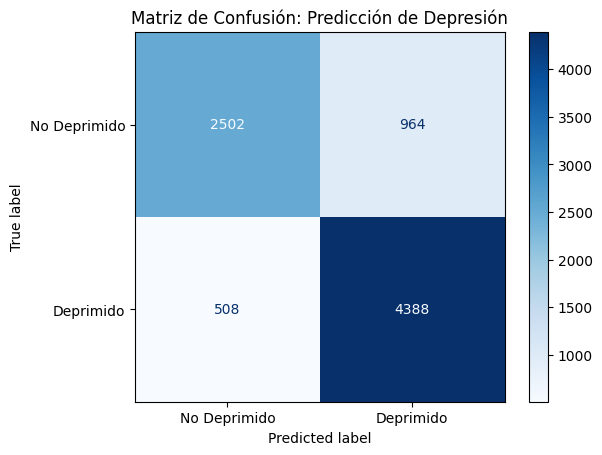

In [ ]:
# Predicciones
y_pred = arbol_depresion.predict(X_test)

# Reporte de métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=["No Deprimido", "Deprimido"]))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Deprimido", "Deprimido"])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión: Predicción de Depresión")
plt.show()

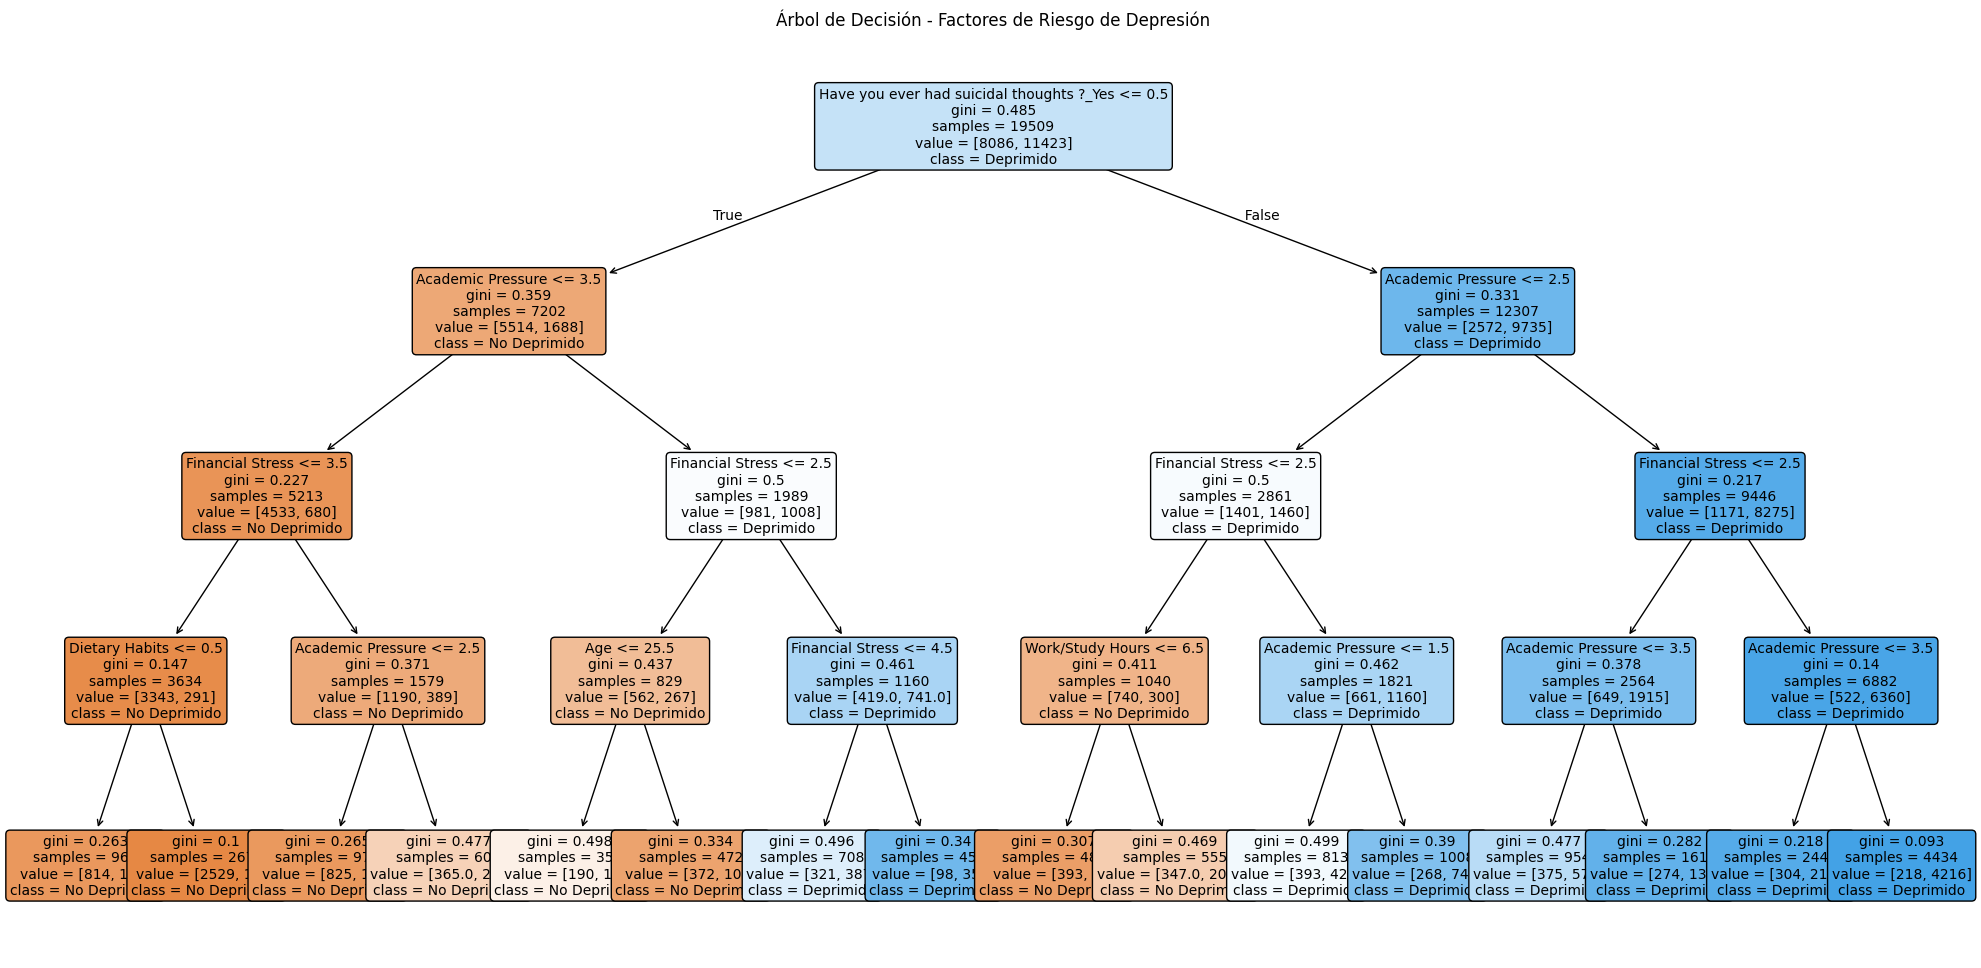

--- Reglas de Decisión del Modelo ---
|--- Have you ever had suicidal thoughts ?_Yes <= 0.50
|   |--- Academic Pressure <= 3.50
|   |   |--- Financial Stress <= 3.50
|   |   |   |--- Dietary Habits <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Dietary Habits >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Financial Stress >  3.50
|   |   |   |--- Academic Pressure <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- Academic Pressure >  2.50
|   |   |   |   |--- class: 0
|   |--- Academic Pressure >  3.50
|   |   |--- Financial Stress <= 2.50
|   |   |   |--- Age <= 25.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  25.50
|   |   |   |   |--- class: 0
|   |   |--- Financial Stress >  2.50
|   |   |   |--- Financial Stress <= 4.50
|   |   |   |   |--- class: 1
|   |   |   |--- Financial Stress >  4.50
|   |   |   |   |--- class: 1
|--- Have you ever had suicidal thoughts ?_Yes >  0.50
|   |--- Academic Pressure <= 2.50
|   |   |--- Financial Stress <= 2.50
|   |  

In [ ]:
# Visualización gráfica
plt.figure(figsize=(25, 12))
plot_tree(
    arbol_depresion,
    feature_names=X.columns,
    class_names=["No Deprimido", "Deprimido"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión - Factores de Riesgo de Depresión")
plt.show()

# Reglas en formato texto
print("--- Reglas de Decisión del Modelo ---")
print(export_text(arbol_depresion, feature_names=list(X.columns)))

# KNN

In [ ]:
# INTEGRACIÓN DE KNN — IMPORTACIÓN DE COMPONENTES
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
print("Librerías para KNN cargadas correctamente.")

Librerías para KNN cargadas correctamente.


In [ ]:
# Inicializamos el modelo con un k inicial estándar de 5 vecinos
knn_sin_escalar = KNeighborsClassifier(n_neighbors=5)
knn_sin_escalar.fit(X_train, y_train)
pred_sin_escalar = knn_sin_escalar.predict(X_test)

print("📊 REPORTE DE CLASIFICACIÓN — KNN SIN ESCALADO")
print(classification_report(y_test, pred_sin_escalar, target_names=["No Depresivo", "Depresivo"]))

📊 REPORTE DE CLASIFICACIÓN — KNN SIN ESCALADO
              precision    recall  f1-score   support

No Depresivo       0.78      0.71      0.74      3466
   Depresivo       0.81      0.86      0.83      4896

    accuracy                           0.80      8362
   macro avg       0.79      0.78      0.79      8362
weighted avg       0.80      0.80      0.80      8362



In [ ]:
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# El pipeline entrena el escalador y el modelo usando solo el conjunto de train
pipeline_knn.fit(X_train, y_train)
pred_knn = pipeline_knn.predict(X_test)

print("⚡ REPORTE DE CLASIFICACIÓN — KNN CON ESCALADO (k=5)")
print(classification_report(y_test, pred_knn, target_names=["No Depresivo", "Depresivo"]))

⚡ REPORTE DE CLASIFICACIÓN — KNN CON ESCALADO (k=5)
              precision    recall  f1-score   support

No Depresivo       0.80      0.71      0.76      3466
   Depresivo       0.81      0.88      0.84      4896

    accuracy                           0.81      8362
   macro avg       0.81      0.80      0.80      8362
weighted avg       0.81      0.81      0.81      8362



In [ ]:
def calcular_metricas(nombre_modelo, y_real, y_pred):
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1-Score": f1_score(y_real, y_pred)
    }

df_comparacion_escalas = pd.DataFrame([
    calcular_metricas("KNN sin escalado", y_test, pred_sin_escalar),
    calcular_metricas("KNN con escalado (k=5)", y_test, pred_knn)
])

print("📋 Tabla comparativa de impacto de escala:")
df_comparacion_escalas

📋 Tabla comparativa de impacto de escala:


,Modelo,Accuracy,Precision,Recall,F1-Score
0,KNN sin escalado,0.797297,0.806550,0.860090,0.832460
1,KNN con escalado (k=5),0.809256,0.812181,0.877042,0.843366


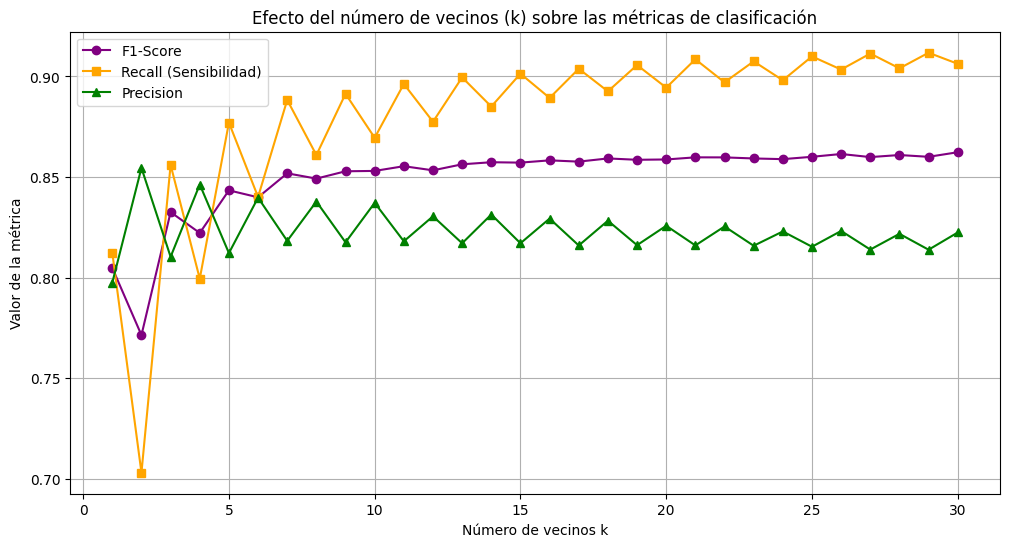

🔝 Top 5 mejores valores de K observados:


,k,Accuracy,Precision,Recall,F1-Score
29,30,0.830543,0.822428,0.906250,0.862307
25,26,0.829825,0.823190,0.903391,0.861428
27,28,0.828988,0.821760,0.904003,0.860922
24,25,0.826597,0.815337,0.909926,0.860039
28,29,0.826238,0.813856,0.911765,0.860033


In [ ]:
valores_k = list(range(1, 31))
resultados_k = []

for k in valores_k:
    modelo_iterado = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo_iterado.fit(X_train, y_train)
    pred_test = modelo_iterado.predict(X_test)

    resultados_k.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, pred_test),
        "Precision": precision_score(y_test, pred_test),
        "Recall": recall_score(y_test, pred_test),
        "F1-Score": f1_score(y_test, pred_test)
    })

df_curva_k = pd.DataFrame(resultados_k)

# Visualización gráfica de las métricas según K
plt.figure(figsize=(12, 6))
plt.plot(df_curva_k["k"], df_curva_k["F1-Score"], marker="o", label="F1-Score", color="purple")
plt.plot(df_curva_k["k"], df_curva_k["Recall"], marker="s", label="Recall (Sensibilidad)", color="orange")
plt.plot(df_curva_k["k"], df_curva_k["Precision"], marker="^", label="Precision", color="green")
plt.title("Efecto del número de vecinos (k) sobre las métricas de clasificación")
plt.xlabel("Número de vecinos k")
plt.ylabel("Valor de la métrica")
plt.legend()
plt.grid(True)
plt.show()

# Mostramos los 5 mejores valores de k según el F1-Score
print("🔝 Top 5 mejores valores de K observados:")
df_curva_k.sort_values("F1-Score", ascending=False).head(5)

📌 Entrenando el modelo final con el mejor k encontrado: 30

📝 REPORTE FINAL DEL MODELO KNN OPTIMIZADO
              precision    recall  f1-score   support

No Depresivo       0.85      0.72      0.78      3466
   Depresivo       0.82      0.91      0.86      4896

    accuracy                           0.83      8362
   macro avg       0.83      0.81      0.82      8362
weighted avg       0.83      0.83      0.83      8362



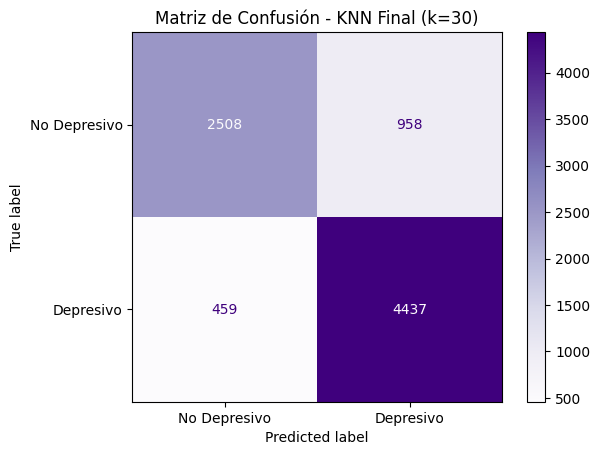

In [ ]:
# Selección automática del mejor k basado en F1-Score
mejor_k = int(df_curva_k.sort_values("F1-Score", ascending=False).iloc[0]["k"])
print(f"📌 Entrenando el modelo final con el mejor k encontrado: {mejor_k}")

knn_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=mejor_k))
])

knn_final.fit(X_train, y_train)
pred_knn_final = knn_final.predict(X_test)

# Reporte final
print("\n📝 REPORTE FINAL DEL MODELO KNN OPTIMIZADO")
print(classification_report(y_test, pred_knn_final, target_names=["No Depresivo", "Depresivo"]))

# Matriz de confusión
cm = confusion_matrix(y_test, pred_knn_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Depresivo", "Depresivo"])
disp.plot(cmap="Purples")
plt.title(f"Matriz de Confusión - KNN Final (k={mejor_k})")
plt.show()

# Random Forest

## Procedimiento realizado

Para aplicar el modelo se realizaron las siguientes etapas:

1. Selección de variables predictoras relacionadas con factores académicos, personales y sociales de los estudiantes.

2. Definición de la variable objetivo correspondiente a la presencia o ausencia de depresión.

3. División del conjunto de datos en entrenamiento, validación y prueba (train, validation y test) para entrenar el modelo y posteriormente evaluar su capacidad de generalización sobre datos no vistos.

4. Entrenamiento del modelo Random Forest utilizando múltiples árboles de decisión.

5. Evaluación del rendimiento mediante métricas de clasificación como Accuracy, Precision, Recall y F1-score.

6. Análisis de la importancia de variables para identificar cuáles factores tienen mayor influencia en la predicción de depresión estudiantil.

---

## Ventajas del modelo

El uso de Random Forest presentó varias ventajas dentro del proyecto:

- Mayor estabilidad en las predicciones.
- Reducción del sobreajuste.
- Buena capacidad de generalización.
- Capacidad para trabajar con múltiples variables.
- Posibilidad de interpretar la importancia de los factores asociados a la depresión.

In [ ]:

# RANDOM FOREST


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns


# DEFINIR DATASET


# Usamos una copia del dataset limpio
df_modelo = df2.copy()

# Verificar columnas
df_modelo.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Sleep_enc,Dietary_enc,Suicidal_enc,Family_History_enc,Gender_enc,pressure_index,healthy_habits,academic_efficiency,risk_profile
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,1.0,2.0,1,0,0,6.0,4.0,2.894,9.0
1,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0,1.0,1.0,0,1,1,4.0,3.0,1.903,5.0
2,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0,0.0,2.0,0,1,0,4.0,2.0,0.773,5.0
3,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1,2.0,1.0,1,1,1,8.0,5.0,1.363,12.0
4,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0,1.0,1.0,1,0,1,5.0,3.0,7.391,8.0


# Definición del dataset base


---



En esta etapa se seleccionó el conjunto de datos limpio y previamente procesado que sería utilizado para el entrenamiento del modelo de clasificación.

Se trabajó con una copia del dataset transformado con el fin de evitar modificaciones sobre los datos originales y garantizar un flujo de trabajo más organizado durante el desarrollo del proyecto.

In [ ]:

# SEPARAR VARIABLE OBJETIVO Y VARIABLES PREDICTORAS


TARGET = 'Depression'

X = df_modelo.drop(columns=[TARGET])
y = df_modelo[TARGET]

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (27875, 22)
Tamaño de y: (27875,)


# Separación de variables predictoras y variable objetivo


---



Posteriormente se definieron las variables predictoras y la variable objetivo.

Las variables predictoras corresponden a los factores académicos, personales y sociales utilizados por el modelo para realizar las predicciones, mientras que la variable objetivo corresponde a la presencia o ausencia de depresión estudiantil.

Esta separación es fundamental para entrenar correctamente el modelo de aprendizaje supervisado.

In [ ]:

# APLICAR ONE HOT ENCODING


X_encoded = pd.get_dummies(X, drop_first=True)

print("Tamaño después de One Hot Encoding:", X_encoded.shape)
X_encoded.head()

Tamaño después de One Hot Encoding: (27875, 81)


,Age,Academic Pressure,CGPA,Study Satisfaction,Work/Study Hours,Financial Stress,Sleep_enc,Dietary_enc,Suicidal_enc,Family_History_enc,Gender_enc,pressure_index,healthy_habits,academic_efficiency,risk_profile,Gender_Male,City_Ahmedabad,City_Bangalore,City_Bhopal,City_Chennai,City_Delhi,City_Faridabad,City_Ghaziabad,City_Hyderabad,City_Indore,City_Jaipur,City_Kalyan,City_Kanpur,City_Kolkata,City_Lucknow,City_Ludhiana,City_Meerut,City_Mumbai,City_Nagpur,City_Nashik,City_Patna,City_Pune,City_Rajkot,City_Srinagar,City_Surat,City_Thane,City_Vadodara,City_Varanasi,City_Vasai-Virar,City_Visakhapatnam,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Degree_B.Com,Degree_B.Ed,Degree_B.Pharm,Degree_B.Tech,Degree_BA,Degree_BBA,Degree_BCA,Degree_BE,Degree_BHM,Degree_BSc,Degree_Class 12,Degree_LLB,Degree_LLM,Degree_M.Com,Degree_M.Ed,Degree_M.Pharm,Degree_M.Tech,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,33.0,5.0,8.97,2.0,3.0,1.0,1.0,2.0,1,0,0,6.0,4.0,2.894,9.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,24.0,2.0,5.90,5.0,3.0,2.0,1.0,1.0,0,1,1,4.0,3.0,1.903,5.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,31.0,3.0,7.03,5.0,9.0,1.0,0.0,2.0,0,1,0,4.0,2.0,0.773,5.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,28.0,3.0,5.59,2.0,4.0,5.0,2.0,1.0,1,1,1,8.0,5.0,1.363,12.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,25.0,4.0,8.13,3.0,1.0,1.0,1.0,1.0,1,0,1,5.0,3.0,7.391,8.0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False


# Aplicación de One Hot Encoding



---



En esta etapa se aplicó la técnica One Hot Encoding sobre las variables categóricas del dataset.

El objetivo de esta transformación fue convertir las categorías de texto en variables numéricas binarias, permitiendo que el modelo Random Forest pudiera procesar correctamente la información.

Además, esta técnica evita que el modelo interprete las categorías como valores numéricos con un orden jerárquico inexistente.

In [ ]:

# 4. DIVISIÓN TRAIN / VALIDATION / TEST
# 60% entrenamiento, 20% validación, 20% prueba


X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (16725, 81)
Validation: (5575, 81)
Test: (5575, 81)


# División del conjunto de datos


---



El conjunto de datos fue dividido en tres subconjuntos:

- entrenamiento (train),
- validación (validation),
- y prueba (test).

La división permitió entrenar el modelo utilizando una parte de los datos y posteriormente evaluar su capacidad de generalización sobre registros no vistos durante el entrenamiento.

Se utilizó una distribución aproximada de:

- 60% entrenamiento,
- 20% validación,
- 20% prueba.

In [ ]:

# 5. ENTRENAMIENTO RANDOM FOREST


rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

# Entrenamiento del modelo Random Forest


---



Se implementó el algoritmo Random Forest utilizando múltiples árboles de decisión para realizar el proceso de clasificación.

El modelo fue entrenado utilizando el conjunto de entrenamiento, permitiendo identificar patrones relacionados con factores asociados a la depresión estudiantil.

Adicionalmente, se utilizó la opción `class_weight='balanced'` para manejar posibles desbalances entre estudiantes con y sin depresión.

In [ ]:

# 6. EVALUACIÓN DEL MODELO


resultados_rf = {}

for nombre, X_split, y_split in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    y_pred = rf_model.predict(X_split)
    y_prob = rf_model.predict_proba(X_split)[:, 1]

    resultados_rf[nombre] = {
        "Accuracy": accuracy_score(y_split, y_pred),
        "Precision": precision_score(y_split, y_pred),
        "Recall": recall_score(y_split, y_pred),
        "F1-Score": f1_score(y_split, y_pred),
        "ROC-AUC": roc_auc_score(y_split, y_prob)
    }

df_resultados_rf = pd.DataFrame(resultados_rf).T
df_resultados_rf.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Train,1.0000,1.0000,1.0000,1.0000,1.0000
Validation,0.8436,0.8592,0.8765,0.8678,0.9181
Test,0.8352,0.8546,0.8658,0.8601,0.9083


# Evaluación del modelo

Después del entrenamiento se evaluó el desempeño del modelo utilizando los conjuntos de validación y prueba.

Para medir la calidad de las predicciones se calcularon diferentes métricas de clasificación como:

- Accuracy,
- Precision,
- Recall,
- F1-Score,
- y ROC-AUC.

Estas métricas permitieron analizar la capacidad predictiva del modelo y su comportamiento frente al problema de clasificación planteado.

In [ ]:

# 7. REPORTE DE CLASIFICACIÓN EN TEST


y_test_pred_rf = rf_model.predict(X_test)

print(classification_report(
    y_test,
    y_test_pred_rf,
    target_names=["Sin Depresión", "Con Depresión"]
))

               precision    recall  f1-score   support

Sin Depresión       0.81      0.79      0.80      2311
Con Depresión       0.85      0.87      0.86      3264

     accuracy                           0.84      5575
    macro avg       0.83      0.83      0.83      5575
 weighted avg       0.83      0.84      0.83      5575



El modelo Random Forest original ya presentaba un desempeño sólido en la clasificación de estudiantes con y sin depresión.

Las métricas obtenidas mostraron valores cercanos al 83% en accuracy y superiores al 85% en Recall y F1-Score para la clase correspondiente a depresión, indicando una buena capacidad predictiva del modelo.

Sin embargo, durante el entrenamiento se observaron métricas perfectas sobre el conjunto train, lo que sugirió la posible presencia de sobreajuste.

Por esta razón, posteriormente se realizó un ajuste de hiperparámetros con el objetivo de mejorar la capacidad de generalización del modelo y obtener un comportamiento más estable frente a datos no vistos.

# Reporte de clasificación


---



Se generó un reporte de clasificación con el objetivo de analizar el rendimiento del modelo para cada clase.

Este reporte permitió observar métricas individuales para estudiantes con y sin depresión, facilitando la interpretación de los aciertos y errores del modelo durante el proceso de clasificación.

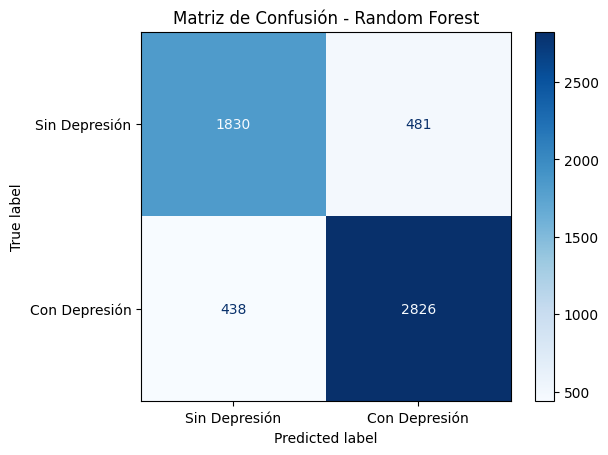

In [ ]:

# 8. MATRIZ DE CONFUSIÓN


cm_rf = confusion_matrix(y_test, y_test_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Sin Depresión", "Con Depresión"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Matriz de confusión

La matriz de confusión permitió visualizar de manera gráfica la cantidad de predicciones correctas e incorrectas realizadas por el modelo.

A través de esta representación fue posible identificar:

- verdaderos positivos,
- verdaderos negativos,
- falsos positivos,
- y falsos negativos.

Esto ayudó a comprender mejor el comportamiento del modelo frente a los distintos tipos de clasificación.

In [ ]:

# 9. IMPORTANCIA DE VARIABLES

importancias_rf = pd.DataFrame({
    "Variable": X_encoded.columns,
    "Importancia": rf_model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias_rf.head(15)

,Variable,Importancia
14,risk_profile,0.166685
79,Have you ever had suicidal thoughts ?_Yes,0.085386
11,pressure_index,0.083650
8,Suicidal_enc,0.077980
1,Academic Pressure,0.066931
13,academic_efficiency,0.055465
0,Age,0.051851
2,CGPA,0.046446
4,Work/Study Hours,0.037068
5,Financial Stress,0.035316


# Importancia de variables


---



Se realizó un análisis de importancia de variables para identificar cuáles factores tuvieron mayor influencia en las predicciones realizadas por el modelo Random Forest.

Este análisis permitió determinar qué características del dataset aportaron más información al proceso de clasificación de depresión estudiantil.

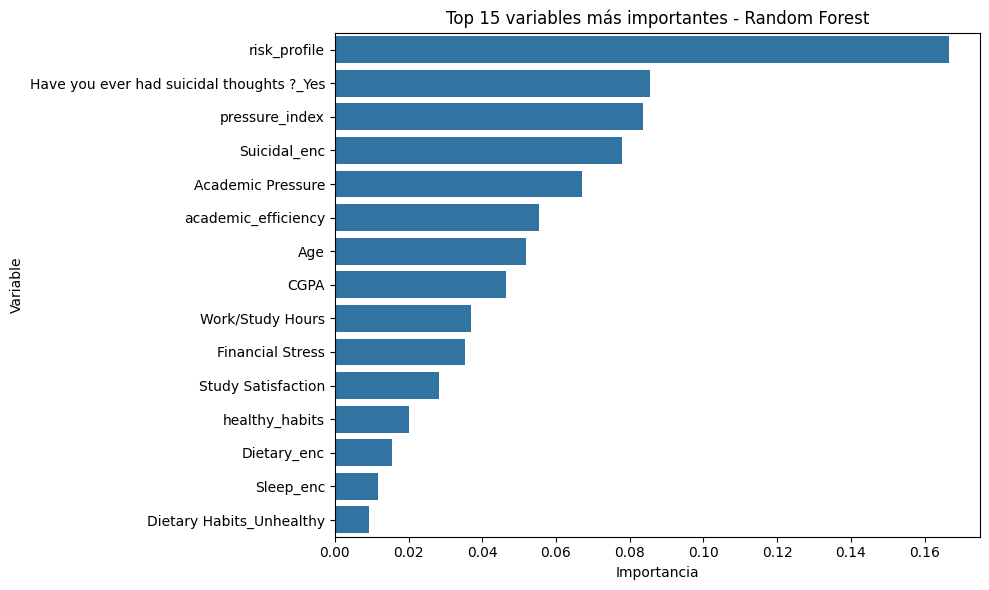

In [ ]:

# 10. GRÁFICA DE IMPORTANCIA DE VARIABLES

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancias_rf.head(15),
    x="Importancia",
    y="Variable"
)

plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# Visualización de importancia de variables


---



Finalmente, se generó una gráfica con las variables más importantes identificadas por el modelo.

Esta visualización facilitó la interpretación de los resultados y permitió observar de manera más clara cuáles factores presentaron mayor impacto en la predicción de depresión estudiantil.

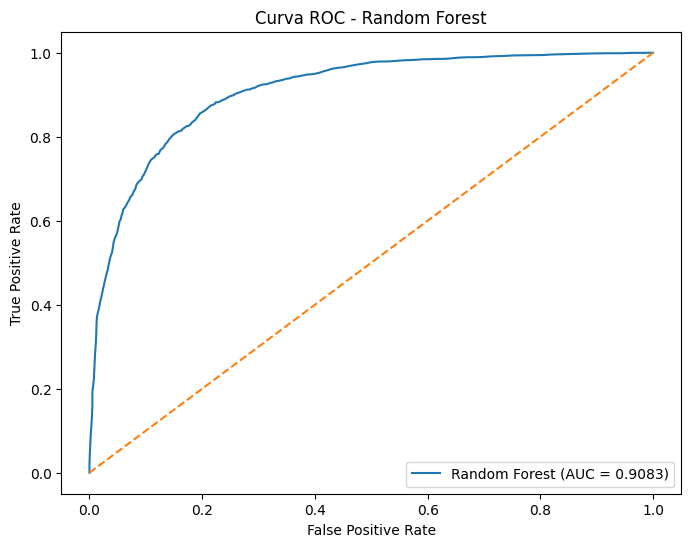

In [ ]:

# 11. CURVA ROC


from sklearn.metrics import roc_curve, auc

# Probabilidades para clase positiva
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Calcular AUC
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Curva ROC - Random Forest')

plt.legend(loc='lower right')

plt.show()

# Curva ROC

Con el objetivo de analizar de manera más detallada la capacidad de clasificación del modelo, se generó la curva ROC (Receiver Operating Characteristic).

Esta curva permite visualizar el comportamiento del modelo al comparar:

- la tasa de verdaderos positivos (True Positive Rate),
- y la tasa de falsos positivos (False Positive Rate).

Además, se calculó la métrica ROC-AUC, la cual representa el área bajo la curva ROC y permite medir qué tan bien el modelo logra diferenciar estudiantes con depresión de aquellos que no presentan depresión.

Valores cercanos a 1 indican un excelente desempeño del modelo, mientras que valores cercanos a 0.5 representan un comportamiento similar a una clasificación aleatoria.

La curva ROC permitió evaluar la capacidad del modelo para diferenciar correctamente estudiantes con y sin depresión. El valor ROC-AUC obtenido fue superior a 0.90, indicando un excelente desempeño de clasificación.

In [ ]:

# 12. AJUSTE DE HIPERPARÁMETROS


from sklearn.model_selection import GridSearchCV

# Definir parámetros a evaluar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Modelo base
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar búsqueda
grid_search.fit(X_train, y_train)

# Mejores parámetros
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Mejor modelo
best_rf = grid_search.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:

# EVALUACIÓN DEL MEJOR MODELO


y_best_pred = best_rf.predict(X_test)
y_best_prob = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_best_pred,
    target_names=['Sin Depresión', 'Con Depresión']
))

print("\nROC-AUC:",
      roc_auc_score(y_test, y_best_prob))

               precision    recall  f1-score   support

Sin Depresión       0.80      0.80      0.80      2311
Con Depresión       0.86      0.86      0.86      3264

     accuracy                           0.83      5575
    macro avg       0.83      0.83      0.83      5575
 weighted avg       0.83      0.83      0.83      5575


ROC-AUC: 0.9088107495269852


# Interpretación final de resultados

El modelo Random Forest optimizado presentó un desempeño sólido en la clasificación de estudiantes con y sin depresión.

Las métricas obtenidas muestran un accuracy cercano al 83%, indicando que el modelo logra clasificar correctamente una gran proporción de los registros analizados.

Asimismo, las métricas Precision y Recall alcanzaron valores cercanos al 86% para la clase correspondiente a estudiantes con depresión, lo que evidencia una buena capacidad tanto para identificar casos reales como para reducir clasificaciones incorrectas.

El valor F1-Score mostró un equilibrio adecuado entre precisión y capacidad de detección, reflejando un comportamiento estable del modelo.

Adicionalmente, la métrica ROC-AUC obtuvo un valor aproximado de 0.91, indicando una excelente capacidad del modelo para diferenciar estudiantes con depresión de aquellos que no presentan depresión.

Finalmente, el ajuste de hiperparámetros permitió mejorar la capacidad de generalización del modelo y reducir parcialmente el sobreajuste observado durante el entrenamiento inicial.

# Ajuste de hiperparámetros

Con el fin de mejorar el desempeño del modelo Random Forest, se realizó un proceso de ajuste de hiperparámetros utilizando GridSearchCV.

Este procedimiento permite probar múltiples combinaciones de parámetros automáticamente y seleccionar aquella configuración que genera el mejor desempeño durante el entrenamiento.

Entre los hiperparámetros evaluados se encuentran:

- número de árboles,
- profundidad máxima,
- cantidad mínima de muestras por división,
- y cantidad mínima de muestras por hoja.

El objetivo de este proceso fue optimizar la capacidad predictiva del modelo y reducir posibles problemas de sobreajuste.

## Interpretación general del modelo Random Forest

El modelo Random Forest fue aplicado con el objetivo de mejorar la clasificación de la variable asociada a depresión estudiantil.  Este algoritmo fue seleccionado porque combina múltiples árboles de decisión, lo que nos permite reducir la inestabilidad y el sobreajuste que puede presentar un único árbol.

La división de datos en entrenamiento, validación y prueba permitió construir una evaluación más ordenada del modelo. El conjunto de entrenamiento se usó para aprender patrones, el conjunto de validación para ajustar y comparar configuraciones, y el conjunto de prueba para realizar la evaluación final.

Además, se utilizó `class_weight="balanced"` para reducir el impacto de un posible desbalance en la variable objetivo. Esta decisión es importante porque en problemas relacionados con depresión estudiantil no se desea que el modelo ignore la clase menos frecuente.

El ajuste de hiperparámetros mediante `GridSearchCV` permitió buscar una configuración más adecuada del modelo. La métrica seleccionada para este ajuste fue el F1-score, ya que combina precision y recall. Esta elección es apropiada porque el problema no se limita a acertar en general, sino a detectar correctamente los posibles casos de depresión manteniendo un equilibrio con los falsos positivos.

La matriz de confusión permitió analizar los errores del modelo con mayor detalle. En particular, los falsos negativos son relevantes porque representan estudiantes que podrían presentar depresión pero que el modelo clasificó como no depresión.

La curva ROC y el valor AUC permitieron evaluar la capacidad general del modelo para distinguir entre las clases. Un valor AUC alto indica que el modelo separa adecuadamente los casos positivos y negativos.

Finalmente, la importancia de variables permitió identificar cuáles factores aportaron más información al modelo. Esto fortalece el análisis porque no solo se obtiene una predicción, sino también una interpretación de los factores más relacionados con la clasificación.

# Modelo Regresion Lineal para la Prediccion del Rendimiento Academico


---



## Implementacion de Regresion

En las secciones anteriores hemos trabajado con modelos de **clasificacion**, donde el objetivo era predecir si un estudiante presenta depresion (variable binaria 0/1). La regresion lineal, en cambio, requiere una variable objetivo numerica continua, por lo que en esta seccion cambiamos la pregunta:

> ¿Es posible predecir el rendimiento academico (CGPA) de un estudiante a partir de sus condiciones de presion, estres, habitos y bienestar mental?

**¿Por que CGPA como variable objetivo?**

El dataset cuenta con varias variables numericas, pero `CGPA` es la mas adecuada para regresion lineal porque toma 332 valores distintos en el rango de 0 a 10, lo que la convierte en una variable verdaderamente continua. Ademas, el rendimiento academico tiene una relacion teorica directa con las variables de presion, satisfaccion y bienestar que ya forman parte del dataset.

**Proposito:**
1. Preparar los datos seleccionando las variables predictoras numericas relevantes.
2. Escalar las variables para que los coeficientes sean comparables entre si.
3. Entrenar un modelo de regresion lineal e interpretar sus coeficientes.
4. Evaluar el desempeno mediante MAE, RMSE y R2.
5. Visualizar los resultados y analizar la distribucion de errores.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# Preparacion del dataset para regresion
# Se eliminan registros con CGPA igual a 0 porque no representan informacion academica valida
df_reg = df[df['CGPA'] > 0].copy()

# Variables predictoras: numericas con relacion teorica con el rendimiento academico
# Depression se incluye como predictor para medir su efecto sobre el CGPA
features_reg = [
    'Academic Pressure',
    'Study Satisfaction',
    'Work/Study Hours',
    'Financial Stress',
    'Age',
    'Depression'
]

X_reg = df_reg[features_reg].copy()
y_reg = df_reg['CGPA'].copy()

# Eliminar filas con nulos en cualquier variable predictora
mask = X_reg.notna().all(axis=1)
X_reg = X_reg[mask]
y_reg = y_reg[mask]

print('Valores nulos por columna:')
print(X_reg.isna().sum())
print(f'\nRegistros disponibles: {len(df_reg):,}')
print(f'\nVariable objetivo - CGPA:')
print(f'  Media:  {y_reg.mean():.4f}')
print(f'  Std:    {y_reg.std():.4f}')
print(f'  Min:    {y_reg.min():.4f}')
print(f'  Max:    {y_reg.max():.4f}')

Valores nulos por columna:
Academic Pressure     0
Study Satisfaction    0
Work/Study Hours      0
Financial Stress      0
Age                   0
Depression            0
dtype: int64

Registros disponibles: 27,892

Variable objetivo - CGPA:
  Media:  7.6586
  Std:    1.4645
  Min:    5.0300
  Max:    10.0000


## Interpretacion

---

En esta seccion `Depression` actua como variable **predictora**, no como variable objetivo. Esto permite medir si la presencia de depresion tiene un efecto sobre el rendimiento academico, lo cual conecta esta seccion con el analisis de clasificacion realizado en las partes anteriores.

Las demas variables fueron seleccionadas porque tienen una relacion teorica directa con el CGPA: la presion academica, las horas dedicadas al estudio, la satisfaccion con el estudio y el estres financiero son factores que inciden en el rendimiento academico.

In [ ]:
# Division en entrenamiento y prueba: 80% / 20%
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=42
)

# Escalado con StandardScaler
# La regresion lineal es sensible a la escala de las variables.
# StandardScaler transforma cada variable para que tenga media=0 y std=1,
# lo que permite comparar los coeficientes entre si directamente.
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(f'Entrenamiento: {X_train_r.shape[0]:,} registros')
print(f'Prueba:        {X_test_r.shape[0]:,} registros')

Entrenamiento: 22,311 registros
Prueba:        5,578 registros


In [ ]:
# Entrenamiento del modelo de Regresion Lineal
# LinearRegression encuentra los coeficientes que minimizan
# la suma de errores al cuadrado entre los valores reales y los predichos.
modelo_rl = LinearRegression()
modelo_rl.fit(X_train_r_sc, y_train_r)

# Predicciones
y_pred_train_r = modelo_rl.predict(X_train_r_sc)
y_pred_test_r  = modelo_rl.predict(X_test_r_sc)

# Tabla de coeficientes
coeficientes = pd.DataFrame({
    'Variable': features_reg,
    'Coeficiente': modelo_rl.coef_
}).sort_values('Coeficiente', ascending=False).reset_index(drop=True)

print(f'Intercepto (b0): {modelo_rl.intercept_:.4f}\n')
print('Coeficientes del modelo (variables estandarizadas):')
print(coeficientes.to_string(index=False))

Intercepto (b0): 7.6552

Coeficientes del modelo (variables estandarizadas):
          Variable  Coeficiente
        Depression     0.057923
               Age     0.010919
  Financial Stress    -0.008185
  Work/Study Hours    -0.009415
 Academic Pressure    -0.066427
Study Satisfaction    -0.072154


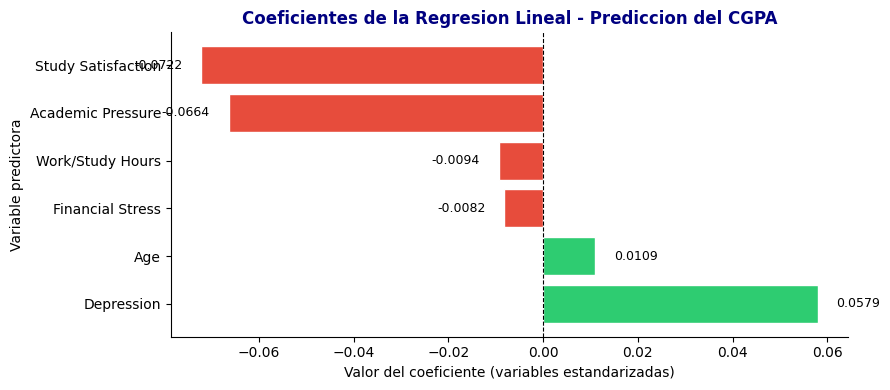

In [ ]:
# Grafico de coeficientes
# Verde: efecto positivo sobre el CGPA | Rojo: efecto negativo sobre el CGPA
colores = ['#2ecc71' if c > 0 else '#e74c3c' for c in coeficientes['Coeficiente']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(coeficientes['Variable'], coeficientes['Coeficiente'],
               color=colores, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes de la Regresion Lineal - Prediccion del CGPA',
             fontsize=12, fontweight='bold', color='navy')
ax.set_xlabel('Valor del coeficiente (variables estandarizadas)')
ax.set_ylabel('Variable predictora')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, coeficientes['Coeficiente']):
    ax.text(val + (0.004 if val >= 0 else -0.004),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

## Interpretacion

---

Los coeficientes del modelo indican cuanto cambia el CGPA predicho cuando esa variable aumenta en una unidad estandar, manteniendo las demas constantes. Como todas las variables estan estandarizadas, sus coeficientes son directamente comparables entre si.

El resultado mas llamativo es que Depression aparece con el coeficiente positivo mas alto (0.0579), lo que indica que en este dataset los estudiantes con depresion tienden a tener un CGPA ligeramente mayor. Esto es contraintuitivo pero es lo que muestran los datos, y puede explicarse porque el CGPA es una medida acumulada que no necesariamente refleja el estado actual del estudiante: un estudiante puede haber acumulado un buen promedio antes de desarrollar sintomas de depresion.

Study Satisfaction aparece con el coeficiente negativo mas alto (-0.0722), seguido de Academic Pressure (-0.0664). Esto sugiere que los estudiantes con mayor satisfaccion y mayor presion academica tienden a reportar CGPAs ligeramente menores, lo cual puede reflejar que estudiantes en programas mas exigentes tienen tanto mayor presion como mayor satisfaccion intelectual pero promedios mas ajustados.

En todo caso, todos los coeficientes son muy pequenos en valor absoluto, lo que sera analizado en detalle con las metricas de evaluacion en la siguiente seccion.

In [ ]:
# Metricas de evaluacion en entrenamiento y prueba
# A diferencia de los modelos de clasificacion, aqui no se usa accuracy.
# Las metricas de regresion miden el error numerico entre el valor real y el predicho.

def calcular_metricas_reg(y_real, y_pred, nombre):
    mae  = mean_absolute_error(y_real, y_pred)
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_real, y_pred)
    return {'Conjunto': nombre, 'MAE': round(mae,4), 'MSE': round(mse,4),
            'RMSE': round(rmse,4), 'R2': round(r2,4)}

resultado_train_r = calcular_metricas_reg(y_train_r, y_pred_train_r, 'Entrenamiento')
resultado_test_r  = calcular_metricas_reg(y_test_r,  y_pred_test_r,  'Prueba')

tabla_metricas_rl = pd.DataFrame([resultado_train_r, resultado_test_r])
print('Metricas de evaluacion - Regresion Lineal')
tabla_metricas_rl

Metricas de evaluacion - Regresion Lineal


,Conjunto,MAE,MSE,RMSE,R2
0,Entrenamiento,1.2666,2.1346,1.4610,0.0044
1,Prueba,1.2701,2.1398,1.4628,0.0035


## Interpretacion

---

Los resultados muestran que el modelo tiene una capacidad predictiva casi nula. El R2 es de 0.0044 en entrenamiento y 0.0035 en prueba, lo que significa que las variables seleccionadas explican menos del 1% de la variabilidad del CGPA. Esto no es un error del modelo sino un hallazgo: el rendimiento academico medido por el CGPA no tiene una relacion lineal con las variables de presion, estres y bienestar disponibles en este dataset.

El MAE de 1.27 y el RMSE de 1.46 indican que en promedio el modelo se equivoca en mas de 1 punto sobre la escala de 10, lo cual es considerable dado que el CGPA del dataset va de 5.03 a 10.

La diferencia entre entrenamiento y prueba es minima, lo que confirma que no hay overfitting. El problema no es que el modelo memorice, sino que directamente no encuentra patrones utiles en estas variables para predecir el CGPA.

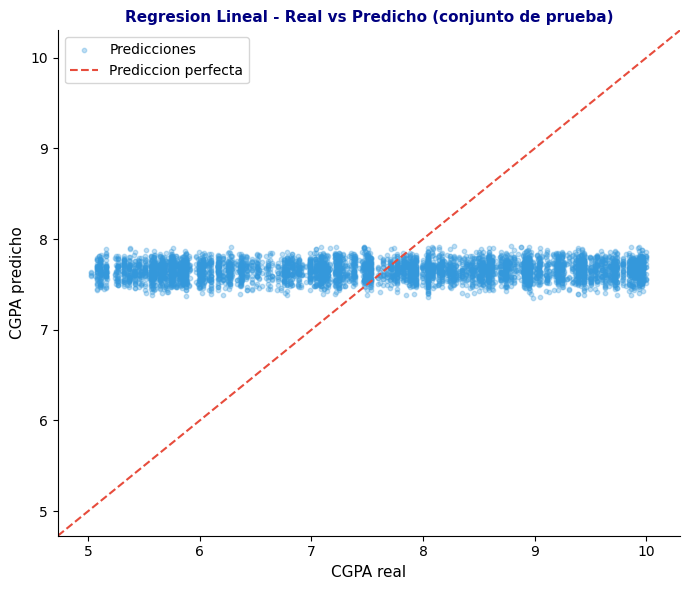

In [ ]:
# Grafico: Valores reales vs valores predichos
# Si el modelo fuera perfecto, todos los puntos caerian sobre la linea diagonal.
# La dispersion alrededor de esa linea refleja el error del modelo.

lim_min = min(y_test_r.min(), y_pred_test_r.min()) - 0.3
lim_max = max(y_test_r.max(), y_pred_test_r.max()) + 0.3

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_r, y_pred_test_r,
           alpha=0.3, s=10, color='#3498db', label='Predicciones')
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='#e74c3c', linewidth=1.5, linestyle='--', label='Prediccion perfecta')
ax.set_xlabel('CGPA real', fontsize=11)
ax.set_ylabel('CGPA predicho', fontsize=11)
ax.set_title('Regresion Lineal - Real vs Predicho (conjunto de prueba)',
             fontsize=11, fontweight='bold', color='navy')
ax.legend()
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

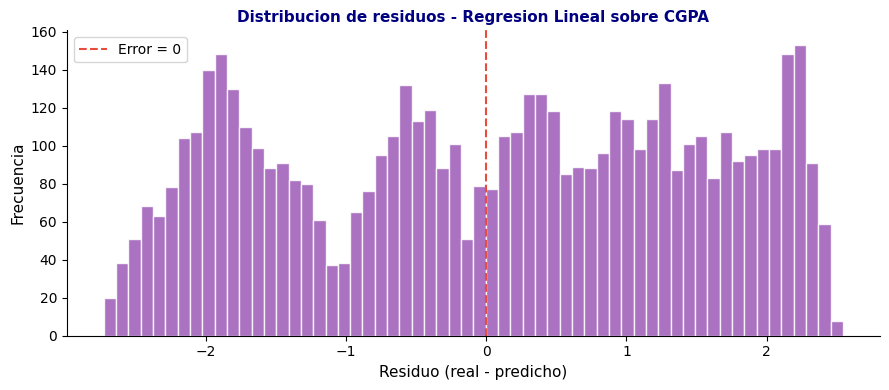

Media de los residuos: 0.016514  (idealmente cercana a 0)
Std de los residuos:   1.4627


In [ ]:
# Distribucion de residuos
# Los residuos son la diferencia entre el valor real y el predicho.
# En un modelo bien calibrado deben distribuirse de forma aproximadamente
# normal y centrada en 0, sin sesgo sistematico hacia ningun lado.

residuos = y_test_r.values - y_pred_test_r

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(residuos, bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=1.5, label='Error = 0')
ax.set_xlabel('Residuo (real - predicho)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribucion de residuos - Regresion Lineal sobre CGPA',
             fontsize=11, fontweight='bold', color='navy')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Media de los residuos: {residuos.mean():.6f}  (idealmente cercana a 0)')
print(f'Std de los residuos:   {residuos.std():.4f}')

## Interpretacion

---

El grafico de real vs predicho confirma lo que anunciaban las metricas: las predicciones forman una banda horizontal plana alrededor de 7.5 sin importar cual sea el CGPA real del estudiante. El modelo predice practicamente el mismo valor para todos los registros, lo que equivale a decir que aprendio muy poco de las variables predictoras.

La distribucion de residuos refuerza este diagnostico. En lugar de tener forma normal centrada en 0, muestra una distribucion bimodal con dos picos claramente separados, lo que indica que hay dos grupos de estudiantes con patrones de CGPA distintos que el modelo no logra diferenciar con las variables disponibles. La media de los residuos es 0.016, cercana a 0, por lo que no hay sesgo sistematico de sobreestimacion o subestimacion, pero la std de 1.46 confirma que los errores son amplios y dispersos.

# Conclusiones - Regresion Lineal

* La regresion lineal aplicada sobre el dataset de depresion estudiantil permitio responder una pregunta distinta a la de las secciones anteriores: en lugar de clasificar si un estudiante presenta depresion, este modelo busco cuantificar como las variables del dataset se asocian con el rendimiento academico medido por el CGPA.

* El resultado principal es que el modelo no logra predecir el CGPA de forma util. El R2 de 0.0035 en prueba indica que las variables de presion, estres financiero, satisfaccion y bienestar explican menos del 1% de la variabilidad del rendimiento academico. Esto es en si mismo un hallazgo relevante: el CGPA no depende linealmente de estas variables dentro de este dataset.

* El analisis de coeficientes arrojo un resultado contraintuitivo: Depression aparece con el coeficiente positivo mas alto, mientras que Study Satisfaction y Academic Pressure tienen los coeficientes negativos mas grandes. Sin embargo, dado el R2 cercano a cero, estos coeficientes no son confiables como guia de interpretacion causal: el modelo no tiene suficiente poder explicativo para que sus coeficientes sean significativos.

* A diferencia de lo observado con el arbol de decision sin limite de profundidad en secciones anteriores, aqui no hay overfitting. Las metricas de entrenamiento y prueba son casi identicas, lo que indica que el problema es underfitting: el modelo es demasiado simple para capturar la estructura real de los datos.

## Seleccion y justificacion de metricas

Se utilizaron MAE, RMSE y R2 como metricas de evaluacion porque cada una responde una pregunta diferente sobre el desempeno del modelo.

El MAE representa el error promedio en unidades reales de CGPA y es la metrica mas facil de interpretar: en este caso indica que el modelo se equivoca en promedio 1.27 puntos sobre una escala de 10. El RMSE complementa al MAE porque penaliza los errores grandes de forma mas severa, lo que permite detectar si hay casos donde el modelo falla de forma notable aunque el promedio parezca aceptable. En este modelo, el RMSE de 1.46 es cercano al MAE, lo que indica que los errores son homogeneos y no hay casos extremos que distorsionen el resultado. El R2 es la metrica que responde si el modelo aprendio algo de los datos: un R2 cercano a cero confirma que las variables seleccionadas no tienen poder explicativo lineal sobre el CGPA.

Como metricas alternativas que podrian complementar este analisis se pueden considerar el MAPE, que expresa el error como porcentaje del valor real y facilita la comunicacion del resultado a audiencias sin contexto tecnico, y el R2 ajustado, que penaliza la inclusion de variables que no aportan al modelo y hubiera sido mas conservador que el R2 simple dado que se usaron 6 predictores.

## Sobre el preprocesamiento de los datos

El modelo se entrenó con las variables escaladas mediante StandardScaler, lo que significa que cada variable fue transformada para tener media 0 y desviacion estandar 1. Esto permite comparar los coeficientes directamente entre variables que originalmente tienen escalas distintas (por ejemplo, Age en anos vs Financial Stress en una escala de 1 a 5); segundo, el modelo converge de forma mas estable numericamente.

Entrenar sin escalar hubiera producido predicciones igualmente validas en terminos numericos, pero los coeficientes no habrian sido comparables entre si, perdiendo la posibilidad de interpretar que variable influye mas sobre el CGPA.

Aplicar PCA antes de la regresion no tendria sentido en este caso por dos razones. Con solo 6 variables predictoras, la reduccion de dimensionalidad no aporta ninguna ventaja computacional ni estadistica. Mas importante, PCA transforma las variables originales en componentes abstractas sin nombre, lo que elimina por completo la interpretabilidad: en lugar de poder decir que Depression o Academic Pressure tienen tal coeficiente, se tendrian componentes sin significado directo.

## Proximos Pasos

Como siguiente paso, seria necesario explorar variables diferentes o construir nuevas variables derivadas que tengan mayor relacion con el CGPA. Tambien seria posible probar un arbol de regresion que capture relaciones no lineales, o replantear la pregunta hacia una variable objetivo distinta donde las variables del dataset si tengan mayor poder predictivo.

# PCA — Análisis de Componentes Principales


---



## Introducción

Con el objetivo de reducir la dimensionalidad del conjunto de datos y analizar la estructura interna de las variables relacionadas con la depresión estudiantil, se aplicó la técnica de Análisis de Componentes Principales (PCA).

El PCA permite transformar un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables llamadas componentes principales, las cuales concentran la mayor cantidad posible de información presente en los datos originales.

Esta técnica resulta útil para:

- reducir redundancia entre variables,
- simplificar el espacio de características,
- facilitar la visualización de datos,
- y analizar si la reducción dimensional afecta el desempeño de los modelos de clasificación.

Los componentes principales obtenidos serán utilizados nuevamente para entrenar modelos de clasificación y comparar su desempeño frente a los modelos construidos con las variables originales.

In [ ]:

# IMPUTACIÓN DE VALORES NULOS


from sklearn.impute import SimpleImputer

# Imputador usando mediana
imputer = SimpleImputer(strategy='median')

# Aplicar imputación
X_imputed = imputer.fit_transform(X_encoded)

# Convertir nuevamente a DataFrame
X_imputed = pd.DataFrame(
    X_imputed,
    columns=X_encoded.columns
)

print("NaN restantes:")
print(X_imputed.isna().sum().sum())

NaN restantes:
0


In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
#Aplicar PCA

from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(27875, 81)


# Tratamiento de valores faltantes

Antes de aplicar PCA fue necesario tratar los valores faltantes presentes en el conjunto de datos, debido a que esta técnica no admite registros con valores nulos.

Para solucionar este problema se utilizó imputación por mediana reemplazando los valores faltantes por la mediana de cada variable correspondiente.

Esta estrategia fue seleccionada debido a que resulta menos sensible a valores atípicos y permite conservar la estructura general de los datos sin eliminar registros.

In [ ]:

# 3. TABLA DE VARIANZA EXPLICADA


varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

df_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza explicada': varianza_explicada,
    'Varianza acumulada': varianza_acumulada
})

df_varianza.head(20)

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.049937,0.049937
1,PC2,0.039426,0.089363
2,PC3,0.027071,0.116435
3,PC4,0.024661,0.141096
4,PC5,0.024027,0.165123
5,PC6,0.022213,0.187336
6,PC7,0.018593,0.205929
7,PC8,0.017989,0.223918
8,PC9,0.016390,0.240308
9,PC10,0.014627,0.254935


# Interpretación de la varianza explicada

La varianza explicada representa la cantidad de información del dataset original que logra conservar cada componente principal generado mediante PCA.

Los primeros componentes principales concentran la mayor parte de la variabilidad presente en los datos mientras que los componentes posteriores aportan cantidades menores de información.

Los resultados del PCA muestran que la varianza del dataset se encuentra distribuida entre múltiples componentes principales y no concentrada únicamente en los primeros componentes.

Esto indica que el problema de depresión estudiantil presenta una estructura compleja y multifactorial, donde distintas variables aportan información relevante al análisis.

Debido a esto, los primeros componentes principales explican únicamente una fracción limitada de la varianza total, haciendo necesario conservar una mayor cantidad de componentes para mantener una proporción significativa de la información original.

In [ ]:

# TABLA RESUMEN DE COMPONENTES Y VARIANZA ACUMULADA


resumen_componentes = pd.DataFrame({
    'Número de Componentes': range(1, len(varianza_acumulada)+1),
    'Varianza Acumulada': varianza_acumulada
})

# Mostrar algunos puntos importantes
puntos_interes = [1, 2, 3, 5, 10, 15, 20]

tabla_resumen = resumen_componentes[
    resumen_componentes['Número de Componentes'].isin(puntos_interes)
]

tabla_resumen

,Número de Componentes,Varianza Acumulada
0,1,0.049937
1,2,0.089363
2,3,0.116435
4,5,0.165123
9,10,0.254935
14,15,0.325830
19,20,0.394529


# ¿Cuántos componentes conservar?

La selección del número de componentes principales depende de la cantidad de varianza acumulada que se desee conservar.

Generalmente:

- 70% - 80% → reducción agresiva de dimensionalidad.
- 90% → buena conservación de información.
- 95% → conservación alta de información original.

En este proyecto se analizó la cantidad de componentes necesarios para conservar al menos el 90% y el 95% de la varianza total del dataset.

In [ ]:

# COMPONENTES NECESARIOS PARA DIFERENTES NIVELES DE VARIANZA


niveles_varianza = [0.70, 0.80, 0.90, 0.95]

resultado_componentes = []

for nivel in niveles_varianza:
    n_componentes = np.argmax(varianza_acumulada >= nivel) + 1

    resultado_componentes.append({
        'Varianza Objetivo': f'{int(nivel*100)}%',
        'Número de Componentes': n_componentes
    })

df_componentes = pd.DataFrame(resultado_componentes)

df_componentes

,Varianza Objetivo,Número de Componentes
0,70%,44
1,80%,52
2,90%,61
3,95%,65


Los resultados obtenidos mediante PCA muestran que la información del dataset no se concentra en pocos componentes principales, sino que se distribuye entre múltiples dimensiones.

Para conservar el 90% de la varianza total fue necesario mantener aproximadamente 61 componentes principales, lo que indica que el fenómeno de depresión estudiantil presenta una estructura compleja y multifactorial.

Esto sugiere que múltiples variables académicas, personales y sociales aportan información relevante al problema y que la reducción dimensional mediante PCA no logra simplificar significativamente el conjunto de datos sin perder información importante.

##90% de varianza = 61 componentes

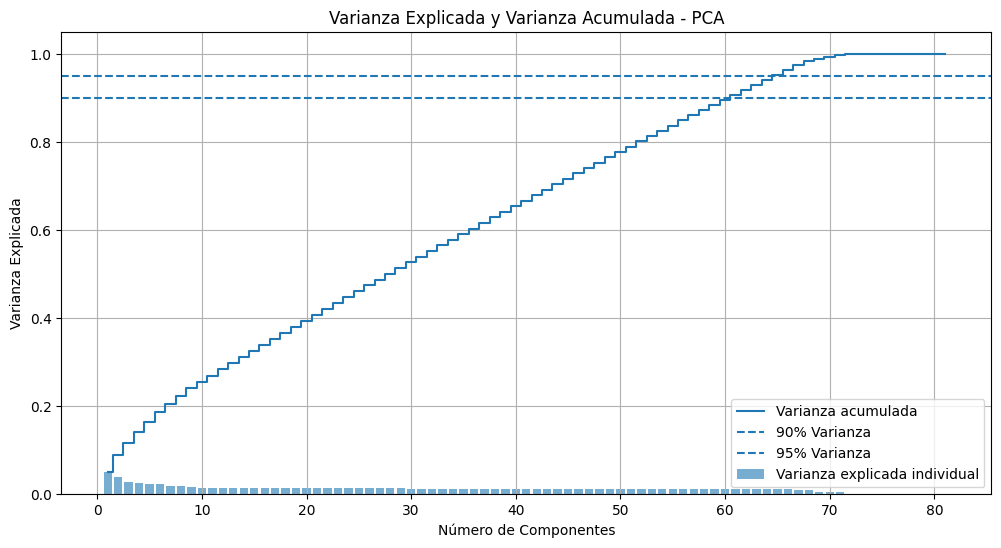

In [ ]:

# VISUALIZACIÓN


plt.figure(figsize=(12,6))

bars = plt.bar(
    range(1, len(varianza_explicada)+1),
    varianza_explicada,
    alpha=0.6,
    label='Varianza explicada individual'
)

plt.step(
    range(1, len(varianza_acumulada)+1),
    varianza_acumulada,
    where='mid',
    label='Varianza acumulada'
)

plt.axhline(
    y=0.90,
    linestyle='--',
    label='90% Varianza'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Varianza'
)

plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada')

plt.title('Varianza Explicada y Varianza Acumulada - PCA')

plt.legend(loc='best')

plt.grid(True)

plt.show()

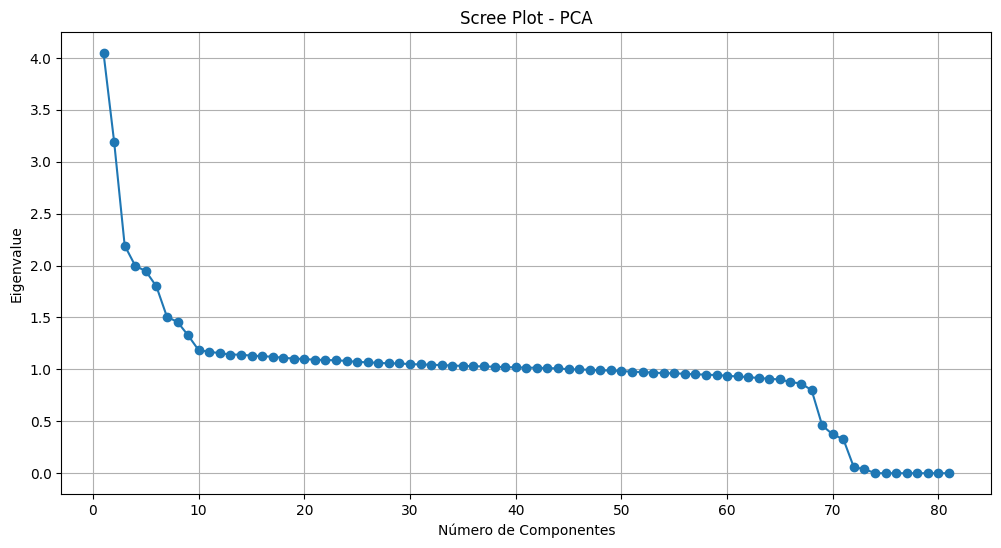

In [ ]:

# GRÁFICO DE CODO (SCREE PLOT)


# Eigenvalues
eigenvalues = pca.explained_variance_

plt.figure(figsize=(12,6))

plt.plot(
    range(1, len(eigenvalues)+1),
    eigenvalues,
    marker='o'
)

plt.xlabel('Número de Componentes')
plt.ylabel('Eigenvalue')

plt.title('Scree Plot - PCA')

plt.grid(True)

plt.show()

# Interpretación del gráfico de codo

El Scree Plot muestra una disminución progresiva de los eigenvalues sin presentar un punto de inflexión extremadamente marcado.

Esto indica que la varianza del dataset se encuentra distribuida entre múltiples componentes principales y no concentrada únicamente en los primeros componentes.

Por esta razón fue necesario conservar una cantidad relativamente alta de componentes para mantener una proporción significativa de la información original del conjunto de datos.

##COMPARACIÓN APLICANDO LOS MODELOS DESPUES DEL PCA

---



# Construcción del dataset reducido con PCA

A partir del análisis de varianza acumulada se seleccionaron 61 componentes principales, los cuales permiten conservar aproximadamente el 90% de la información original del dataset.

Posteriormente, estos componentes fueron utilizados para construir un nuevo conjunto de datos reducido y entrenar nuevamente el modelo Random Forest con el objetivo de comparar su desempeño frente al modelo construido con las variables originales.

In [ ]:

# PCA FINAL - 61 COMPONENTES


# Número de componentes seleccionados
n_componentes = 61

# PCA final
pca_final = PCA(n_components=n_componentes)

X_pca_final = pca_final.fit_transform(X_scaled)

print("Dimensiones originales:", X_scaled.shape)
print("Dimensiones después de PCA:", X_pca_final.shape)

Dimensiones originales: (27875, 81)
Dimensiones después de PCA: (27875, 61)


In [ ]:

# DATAFRAME PCA


df_pca_final = pd.DataFrame(
    X_pca_final,
    columns=[f'PC{i+1}' for i in range(n_componentes)]
)

df_pca_final.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,PC51,PC52,PC53,PC54,PC55,PC56,PC57,PC58,PC59,PC60,PC61
0,-0.211667,-0.081352,-0.010390,-1.180658,2.194982,-1.164530,0.650527,0.922460,0.201518,0.201855,-0.280369,-0.695088,0.216810,1.546532,-0.202396,-0.728400,-0.063532,-1.750630,-0.448850,-1.305414,3.269281,1.347744,0.107748,-1.311078,-0.835450,0.955660,0.648173,1.439830,1.441919,-0.322686,-0.437155,-0.632358,-0.268556,-0.726503,-0.385572,0.661536,1.567225,-0.774475,-1.948177,-0.284236,-1.710046,-0.022444,-0.890296,0.268097,0.495566,-0.065779,-1.119946,0.087846,-0.518607,-0.973516,0.753747,-1.798527,0.285503,-0.185414,-1.477953,0.702815,1.688718,-1.219766,0.574837,1.117943,-0.403825
1,-2.528333,-1.063065,1.940849,1.173975,-1.292520,0.852070,0.116694,-0.426076,-0.289751,1.554173,-0.310541,-0.116942,0.639933,-0.694618,-0.503234,0.767509,-1.387981,0.330403,0.017588,-0.648653,1.420045,-1.018023,0.536157,1.396559,-0.724858,-0.075232,-0.034359,1.511722,-2.343834,-1.364140,-0.159106,-1.131259,0.001101,-1.159102,1.555886,-1.500472,0.599897,0.461894,0.169446,2.375841,0.623339,2.787165,1.166222,-0.293213,-1.456929,1.835974,-0.906420,-1.821178,0.074922,-0.338915,-0.842503,-0.280809,0.642085,0.132300,1.048578,0.233622,1.616843,-0.279050,0.912731,-1.697183,0.451064
2,-2.059607,-2.837392,0.385223,1.856707,0.896004,0.248407,-0.744452,-0.596975,-0.130859,-1.591166,-0.710724,-1.347859,-0.973726,0.286341,-1.923747,0.553280,0.406600,1.434276,0.599900,0.007159,1.728053,1.393803,-1.329345,-0.745697,-0.300558,1.428304,0.284066,-1.071973,-1.531682,-0.854287,1.474390,0.452370,0.038862,-0.108746,-0.227379,0.412073,-1.308359,0.299773,-0.962291,1.459186,2.000735,-0.619894,0.086162,-0.986979,1.069379,-1.025710,-0.971796,-0.267514,-1.792814,1.575871,2.268854,-0.232093,0.914344,0.560420,-0.342859,-3.338623,-0.887405,0.118597,0.510896,-0.379611,-0.465049
3,1.217011,1.615659,2.244361,0.806109,0.190691,-1.112046,-0.145721,0.340129,1.634676,-0.221235,0.193843,0.019079,1.386532,-1.501653,-0.918948,0.099161,-1.325319,-1.459343,1.906861,1.167094,-0.573797,0.456473,-0.641908,-0.141074,0.890388,-0.996654,0.957913,-0.861069,0.458915,-0.255366,-0.219416,1.101900,-1.950324,1.997062,1.493998,-1.393487,-0.149293,0.406135,-0.468281,0.633481,-1.323048,0.239494,1.109641,0.233321,0.482970,-0.681468,1.270755,-1.160102,0.172177,-1.422560,-1.393483,0.230100,-0.519193,-2.233655,-1.241156,-1.473233,-0.373501,-1.221928,-2.136668,-1.258536,-0.244032
4,-0.582072,-0.521344,1.262145,-1.640181,-0.147891,-1.001108,0.229206,1.482455,-0.422164,0.718850,-1.031773,-1.300867,-0.710633,-0.079482,1.282074,1.198288,0.043130,-0.291810,-1.560136,0.352686,-1.364869,1.516339,1.114714,0.540926,0.689352,-0.183858,-1.446115,0.562108,-1.320231,0.091822,0.474879,-1.349421,-0.934654,0.212121,-0.010904,-1.316150,-1.127369,-0.273459,1.657996,0.203550,-0.871943,0.407703,-2.140749,1.204488,-0.376727,-1.825687,-0.266612,-1.575220,-1.033209,-1.458052,0.363680,0.491771,-1.059536,1.058790,-0.131151,0.176165,-0.463566,-1.301401,-0.508093,-0.114001,-0.054830


# Creación del nuevo conjunto de datos PCA

Posteriormente se construyó un nuevo conjunto de datos utilizando únicamente los componentes principales seleccionados.

Cada componente principal representa una dimensión reducida del dataset original y concentra parte de la variabilidad presente en los datos.

In [ ]:

# TRAIN / VALIDATION / TEST CON PCA


X_train_pca, X_temp_pca, y_train_pca, y_temp_pca = train_test_split(
    df_pca_final,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val_pca, X_test_pca, y_val_pca, y_test_pca = train_test_split(
    X_temp_pca,
    y_temp_pca,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_pca
)

print("Train PCA:", X_train_pca.shape)
print("Validation PCA:", X_val_pca.shape)
print("Test PCA:", X_test_pca.shape)

Train PCA: (16725, 61)
Validation PCA: (5575, 61)
Test PCA: (5575, 61)


# Entrenamiento de Random Forest utilizando PCA

Utilizando los componentes principales seleccionados mediante PCA, se entrenó nuevamente el modelo Random Forest.

El objetivo de este experimento fue analizar si la reducción dimensional impacta positiva o negativamente el desempeño del modelo de clasificación.

In [ ]:

# RANDOM FOREST + PCA


from sklearn.ensemble import RandomForestClassifier

rf_pca = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

rf_pca.fit(X_train_pca, y_train_pca)

print("Modelo Random Forest + PCA entrenado correctamente")

Modelo Random Forest + PCA entrenado correctamente


# Entrenamiento del modelo Random Forest utilizando PCA

Utilizando los componentes principales obtenidos mediante PCA, se entrenó nuevamente el modelo Random Forest.

El propósito de este experimento fue analizar si la reducción dimensional mejora o afecta la capacidad predictiva del modelo en el problema de clasificación de depresión estudiantil.

In [ ]:

# EVALUACIÓN RANDOM FOREST + PCA


y_pred_pca = rf_pca.predict(X_test_pca)
y_prob_pca = rf_pca.predict_proba(X_test_pca)[:,1]

print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=['Sin Depresión', 'Con Depresión']
))

print("\nROC-AUC:",
      roc_auc_score(y_test_pca, y_prob_pca))

               precision    recall  f1-score   support

Sin Depresión       0.81      0.78      0.79      2311
Con Depresión       0.85      0.87      0.86      3264

     accuracy                           0.83      5575
    macro avg       0.83      0.82      0.83      5575
 weighted avg       0.83      0.83      0.83      5575


ROC-AUC: 0.9001335524473746


# Evaluación del modelo Random Forest con PCA

Después del entrenamiento, el modelo fue evaluado utilizando el conjunto de prueba.

Para analizar el desempeño del modelo se calcularon nuevamente métricas de clasificación como:

- Accuracy,
- Precision,
- Recall,
- F1-Score,
- y ROC-AUC.

Estas métricas permitieron comparar el desempeño del modelo entrenado con PCA frente al modelo construido con las variables originales.

# Comparación entre Random Forest original y Random Forest con PCA

Finalmente, se realizó una comparación entre el modelo Random Forest original y el modelo Random Forest entrenado utilizando componentes principales obtenidos mediante PCA.

El objetivo de esta comparación fue analizar el impacto de la reducción dimensional sobre la capacidad predictiva del modelo y determinar si PCA logra mejorar el desempeño general del algoritmo.

##Conclusiones

---

Aunque se utilizaron varias métricas de evaluación el Recall tuvo especial importancia dentro del proyecto debido a la naturaleza del problema analizado.

En el contexto de depresión estudiantil, los falsos negativos representan casos donde un estudiante con depresión es clasificado incorrectamente como un estudiante sin depresión, lo cual puede resultar problemático desde el punto de vista del análisis y detección temprana.

Por esta razón, se buscó utilizar modelos con una buena capacidad de detección de casos reales positivos, manteniendo además un equilibrio adecuado mediante métricas como F1-Score y ROC-AUC.
